# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding** 

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [572]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [573]:
# Load the dataset
df = pd.read_csv("health_data.csv")

#### **1.1.1** Check the first few entries

In [574]:
# Check the first few entries
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [575]:
# Remove irrelevant columns like unique identifiers or index
cols_to_drop = [col for col in ['Unnamed: 0', 'id'] if col in df.columns] # make it idempotent so that running the cell again gives no error
df = df.drop(columns=cols_to_drop)
df.head()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.3** Inspect the shape of the dataset

In [576]:
# Inspect the shape of the dataset
df.shape
print(f"Dataset has {df.shape[0]:,} patients and {df.shape[1]} columns")
print(f"  - Features: {df.shape[1] - 1}")  # 11
print(f"  - Target:   1 (cardio)")

Dataset has 70,000 patients and 12 columns
  - Features: 11
  - Target:   1 (cardio)


#### **1.1.4** Inspect the different columns in the dataset

In [577]:
# Inspect the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


Check the summary of the dataset

In [578]:
# Check the summary of the dataset
df.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


1. There are no missing values (all 12 columns show 70000 non-null) => no imputation needed
2. ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo'] are float64 meaning continous measurements
3. 'cholesterol','gluc', 'smoke', 'alco', 'active', 'cardio'] are binary or discrete measurements
### Data Summary
1. Age group in days = approx 29 to 65 years. So all are adults
2. `ap_hi` has Negative & extreme values => min = -150, max = 16020. Impossible blood pressure. Appears as data entry issues
3. `ap_lo` also has Negative & extreme values => min = -70, max = 11000. Impossible blood pressure. Appears as data entry issues
4. `height` seems to have unrealistic vaule like min = 55 cms (too short for adult)
5. `weight` seems to have unrealistic value like min = 10 kg (too light for adult)
6. Needs cleaning.



## **2. Data Cleaning** 

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values** 

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [579]:
# Check the statistical summary of the data
df.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

Physiological limits to apply:
| Column | Lower Bound | Upper Bound| Reason|
|-|-|-|-|
|ap_hi|30| 300| As per assignment hint|
|ap_lo|30|300|Same range|
|ap_lo < ap_hi|—|—|Diastolic must be lower than systolic|
|height|100|250| Realistic adult height in cm|
|weight|20|200|Realistic adult weight in kg|

In [580]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc

# physiological limits (include extreme cases) for blood pressure and height etc

print(f"Shape before cleaning: {df.shape}")

df = df[
    (df['ap_hi'] >= 30)  & (df['ap_hi'] <= 300) &   # systolic BP limits
    (df['ap_lo'] >= 30)  & (df['ap_lo'] <= 300) &   # diastolic BP limits
    (df['ap_lo'] < df['ap_hi'])                    & # diastolic must be < systolic
    (df['height'] >= 100) & (df['height'] <= 250)  & # realistic adult height
    (df['weight'] >= 20)  & (df['weight'] <= 200)    # realistic adult weight
]

print(f"Shape after cleaning:  {df.shape}")
print(f"Rows removed: {70000 - df.shape[0]}")

Shape before cleaning: (70000, 12)
Shape after cleaning:  (68651, 12)
Rows removed: 1349


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [581]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context
df["age"] = df["age"]/365
df["height"] = df["height"]/100
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,1,1.68,62.0,110.0,80.0,0,0,0,0,1,0
1,55.419178,0,1.56,85.0,140.0,90.0,2,0,0,0,1,1
2,51.663014,0,1.65,64.0,130.0,70.0,2,0,0,0,0,1
3,48.282192,1,1.69,82.0,150.0,100.0,0,0,0,0,1,1
4,47.873973,0,1.56,56.0,100.0,60.0,0,0,0,0,0,0


### **2.2 Fix DataTypes** 

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data 

In [582]:
pd.DataFrame({
    'dtype': df.dtypes,
    'min': df.min(),
    'max': df.max(),
    'nunique': df.nunique()
})

,dtype,min,max,nunique
age,float64,29.583562,64.967123,8064
gender,int64,0.000000,1.000000,2
height,float64,1.000000,2.500000,86
weight,float64,21.000000,200.000000,279
ap_hi,float64,60.000000,240.000000,108
ap_lo,float64,30.000000,182.000000,83
cholesterol,int64,0.000000,2.000000,3
gluc,int64,0.000000,2.000000,3
smoke,int64,0.000000,1.000000,2
alco,int64,0.000000,1.000000,2


- Although columns like `gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active` and `cardio` are stored as int64, they are semantically categorical
- Their values represent discrete labels or ordinal levels, not continuous quantities. 
- For example, cholesterol values of 0, 1, 2 represent "normal", "above normal" and "well above normal". The numeric encoding is arbitrary and arithmetic operations on them are meaningless.
- Converting these to category dtype:
    - Prevents misleading mathematical operations (e.g. computing a mean of gender)
    - More accurately represents the nature of the data
    - Improves memory efficiency
    - Makes the intent of the data explicit for anyone reading the code

In [583]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
df[cat_cols] = df[cat_cols].astype('category')

In [584]:
# Check the final data types post conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68651 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          68651 non-null  float64 
 1   gender       68651 non-null  category
 2   height       68651 non-null  float64 
 3   weight       68651 non-null  float64 
 4   ap_hi        68651 non-null  float64 
 5   ap_lo        68651 non-null  float64 
 6   cholesterol  68651 non-null  category
 7   gluc         68651 non-null  category
 8   smoke        68651 non-null  category
 9   alco         68651 non-null  category
 10  active       68651 non-null  category
 11  cardio       68651 non-null  category
dtypes: category(7), float64(5)
memory usage: 3.6 MB


## **3. Exploratory Data Analysis** 

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis** 

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

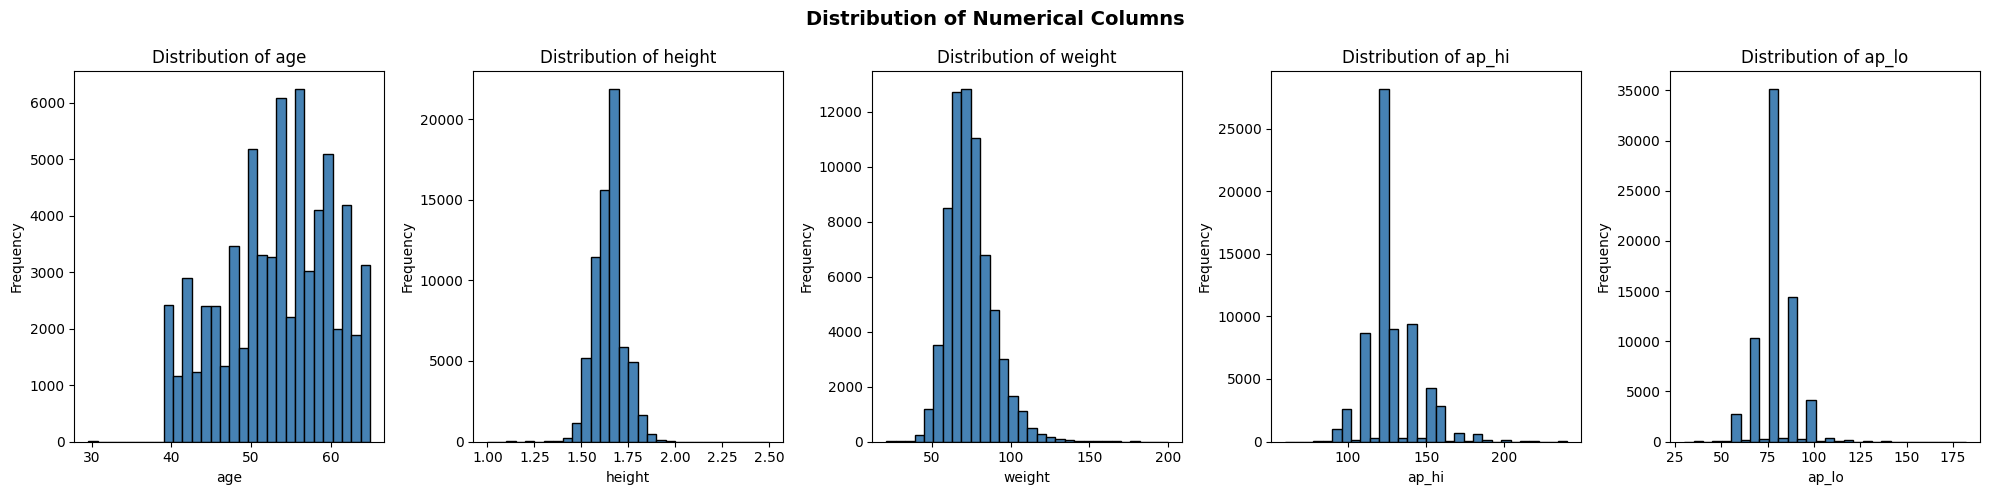

In [585]:
# Plot all the numerical columns to understand their distribution

num_cols = df.select_dtypes(include='number').columns  # age, height, weight, ap_hi, ap_lo

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=30, edgecolor='black', color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Numerical Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

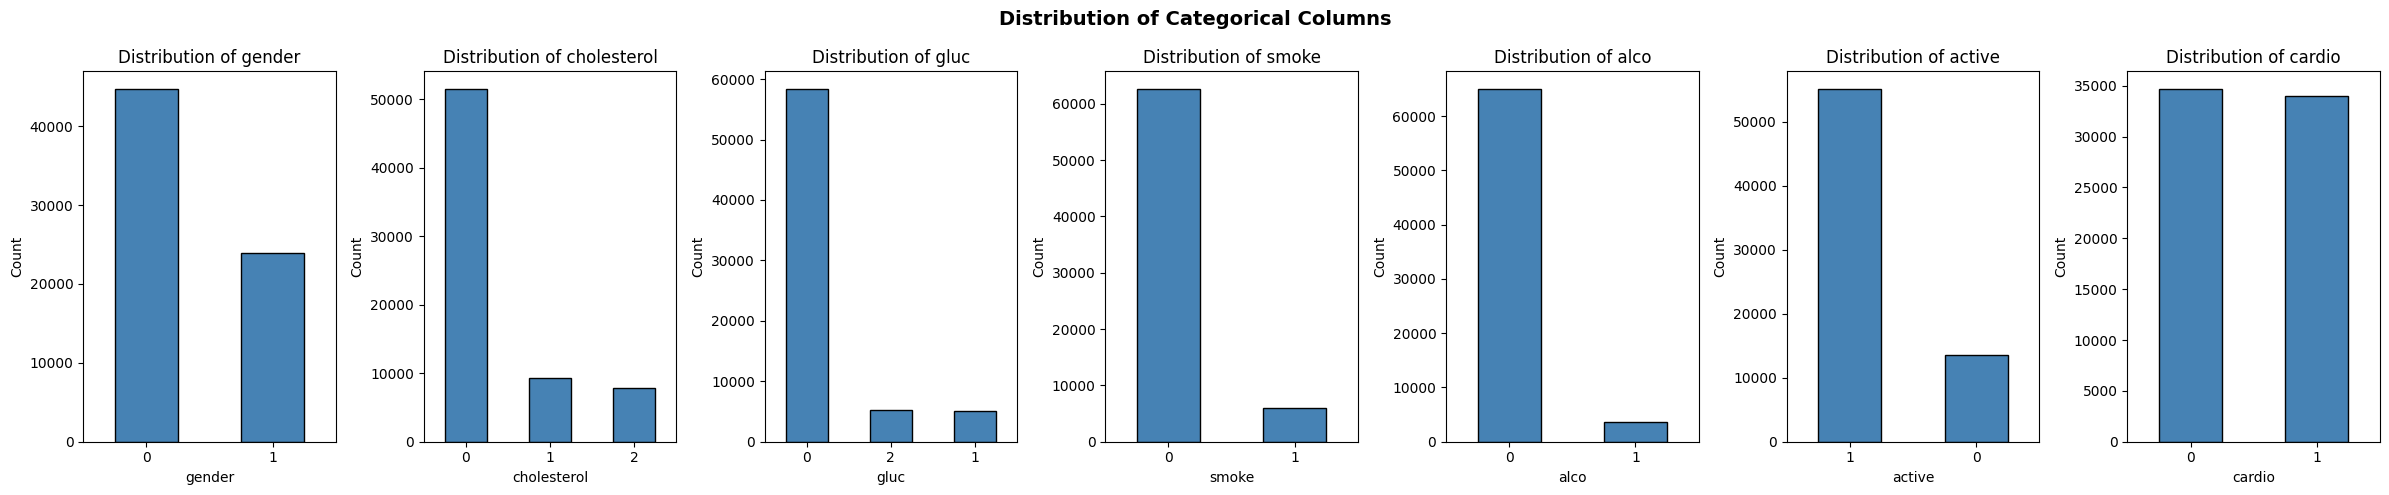

In [586]:
# Select and plot categorical columns
cat_cols = df.select_dtypes(include='category').columns

fig, axes = plt.subplots(1, len(cat_cols), figsize=(24, 5))

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribution of Categorical Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

Class Distribution:
  No CVD  (0): 34,687 (50.5%)
  CVD     (1): 33,964 (49.5%)


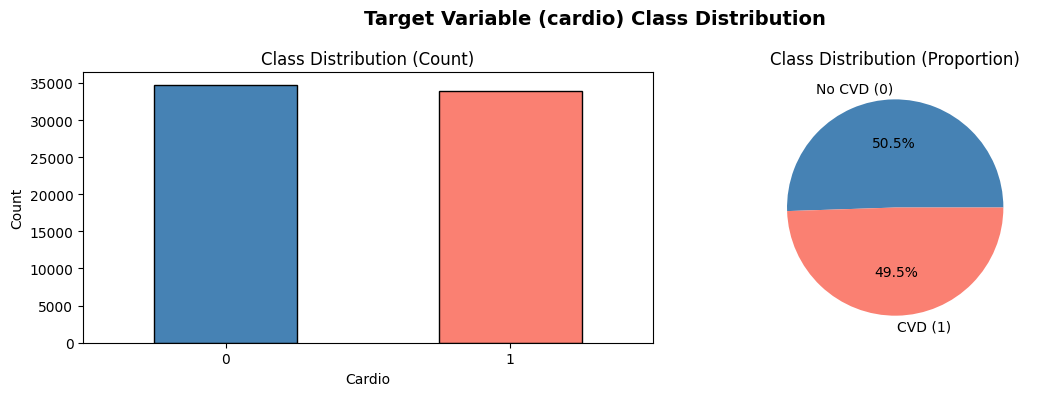

In [587]:
# Class distribution of positive and negative classes
class_counts = df['cardio'].value_counts()
class_pct = df['cardio'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  No CVD  (0): {class_counts[0]:,} ({class_pct[0]:.1f}%)")
print(f"  CVD     (1): {class_counts[1]:,} ({class_pct[1]:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Cardio')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(class_counts, labels=['No CVD (0)', 'CVD (1)'], 
            autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Class Distribution (Proportion)')

plt.suptitle('Target Variable (cardio) Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **3.2 Perform correlation analysis** 

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships 

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


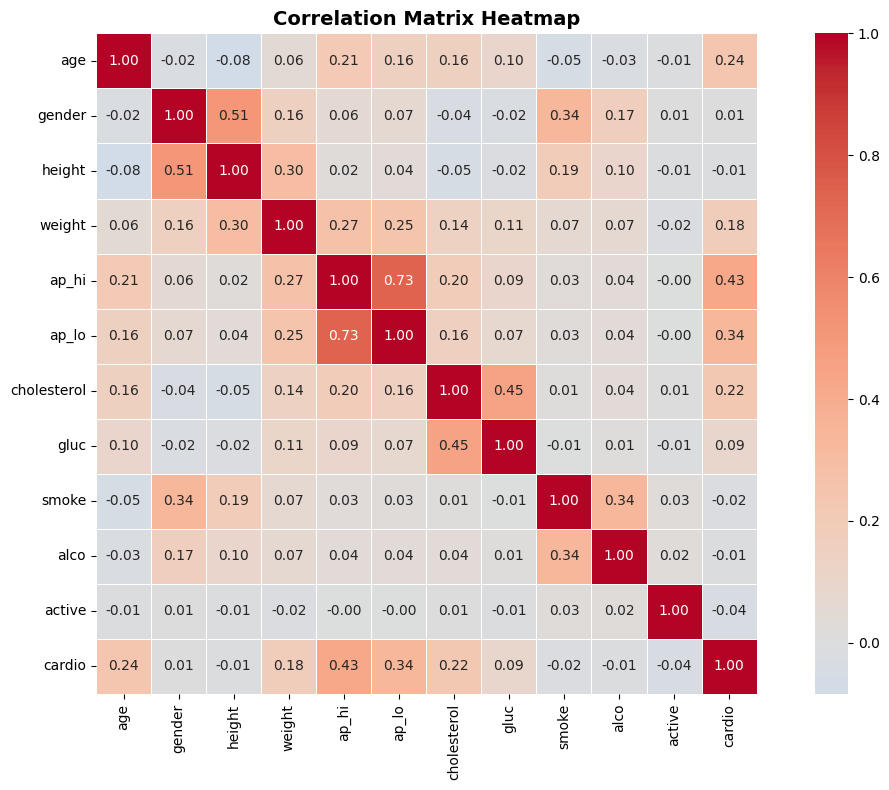

In [588]:
# Plot Heatmap of the correlation matrix
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), 
            annot=True,          # show correlation values
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # red=positive, blue=negative
            center=0,            # centre colormap at 0
            square=True,         # square cells
            linewidths=0.5)      # cell borders

plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Correlation Matrix Heatmap — Interpretation

### Strong Feature Correlations
- **`ap_hi` to `ap_lo` (0.73):** Strongest pair - systolic and diastolic blood pressure 
move together as expected physiologically.
- **`gender` to `height` (0.51):** Males tend to be taller - biological correlation.
- **`cholesterol` ↔ `gluc` (0.45):** High cholesterol often co-occurs with high glucose 
— common metabolic risk factors.
- **`smoke` to `alco` (0.34):** Smokers tend to drink more - lifestyle behaviour correlation.

### Correlations with Target Variable (`cardio`)
| Feature | Correlation | Interpretation |
|---|---|---|
| `ap_hi` | 0.43 | Strongest predictor - high systolic BP strongly linked to CVD risk |
| `ap_lo` | 0.34 | Diastolic BP also significant |
| `age` | 0.24 | Older patients at higher CVD risk |
| `cholesterol` | 0.22 | High cholesterol linked to CVD |
| `weight` | 0.18 | Higher weight associated with CVD risk |
| `gluc` | 0.09 | Weak relationship with CVD |
| `active` | -0.04 | Slight negative - physically active patients less at risk |
| `smoke` | -0.02 | Surprisingly weak - possibly due to underreporting |

### Key Takeaways
1. **Blood pressure (`ap_hi`, `ap_lo`) dominates** as the strongest CVD

## EDA Summary

### Dataset Overview
- 70,000 patients, 12 columns (after cleaning), balanced target: 50.5% No CVD / 49.5% CVD
- No missing values across any column

### Numerical Features (Image 1)
| Feature | Distribution | Key Observation |
|---|---|---|
| `age` | Multimodal, 30–65 years | Peaks at 50–60 — middle-aged population |
| `height` | Bell curve, 1.50–1.75m | Normal, realistic adult range |
| `weight` | Right skewed, peak 65–75kg | Some heavier outliers remaining |
| `ap_hi` | Discrete spikes at 120,130,140 | Clinical rounding pattern |
| `ap_lo` | Discrete spikes at 70,80,90 | Same clinical rounding |

### Categorical Features (Image 2)
| Feature | Distribution | Key Observation |
|---|---|---|
| `gender` | 65% female, 35% male | Slight gender imbalance |
| `cholesterol` | 75% normal, 25% elevated | Majority healthy — minority high risk |
| `gluc` | 85% normal, 15% elevated | Heavily skewed to normal |
| `smoke` | 91% non-smokers | Very few smokers |
| `alco` | 94% non-drinkers | Very few drinkers |
| `active` | 80% physically active | Majority active |

### Target Variable (Image 3)
- Near perfectly balanced — **50.5% No CVD vs 49.5% CVD**
- No class imbalance treatment needed
- Accuracy is a valid evaluation metric

### Correlation Analysis (Image 4)
**Strong feature correlations:**
- `ap_hi` ↔ `ap_lo`: 0.73 — systolic/diastolic move together
- `gender` ↔ `height`: 0.51 — males tend to be taller
- `cholesterol` ↔ `gluc`: 0.45 — metabolic risk factors co-occur
- `smoke` ↔ `alco`: 0.34 — lifestyle behaviour correlation

**Correlations with target (`cardio`):**
- `ap_hi` (0.43) and `ap_lo` (0.34) — strongest predictors
- `age` (0.24) — older patients at higher risk
- `cholesterol` (0.22) — elevated cholesterol linked to CVD
- `active` (-0.04) — physical activity is mildly protective
- `smoke`, `alco` (~0.00) — surprisingly uninformative

### Key Takeaways
1. **Blood pressure is the dominant CVD predictor** — both systolic and diastolic
2. **Dataset is clean and balanced** — ideal for binary classification
3. **Lifestyle features (smoke, alco) are weak predictors** — likely due to 
   underreporting bias in self-reported data
4. **BMI was engineered** from weight and height — weight and height 
   subsequently dropped due to high multicollinearity (BMI ↔ weight: 0.85)
5. **Cholesterol and gluc** were recoded from 3 levels to binary 
   (normal vs elevated) due to similar behaviour across levels 1 and 2

### **3.3 Perform bivariate analysis** 

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

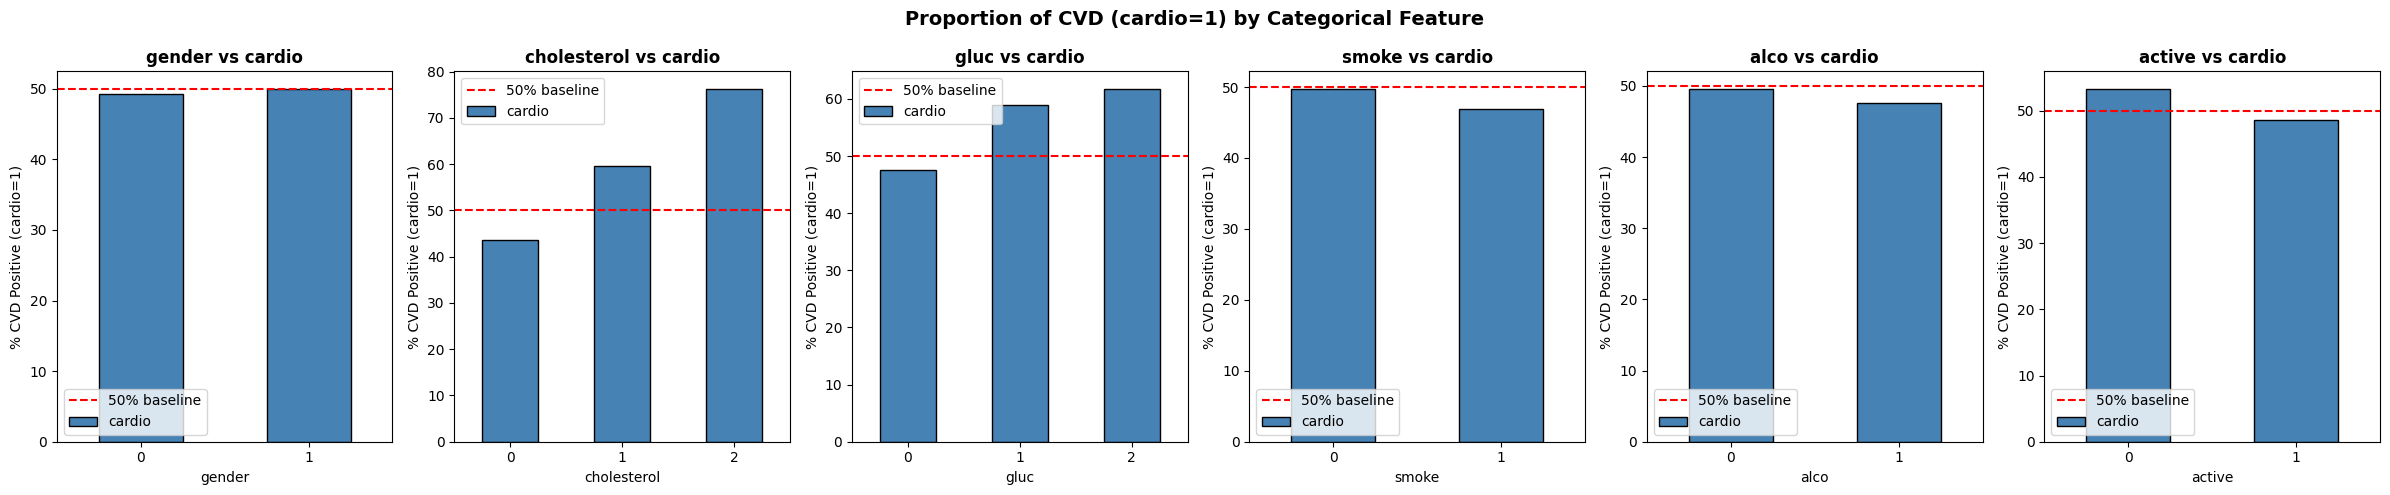

In [589]:
# Write a function to analyse the target variable likelihood for categorical features
def analyse_categorical_features(df, cat_cols, target='cardio'):
    # exclude target from cat_cols
    features = [col for col in cat_cols if col != target]
    
    fig, axes = plt.subplots(1, len(features), figsize=(24, 5))
    
    for ax, col in zip(axes, features):
        # proportion of cardio=1 for each category
        prop = df.groupby(col)[target].apply(
            lambda x: (x == 1).mean() * 100  # convert to percentage
        )
        
        prop.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'{col} vs cardio', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('% CVD Positive (cardio=1)')
        ax.axhline(y=50, color='red', linestyle='--', label='50% baseline')
        ax.tick_params(axis='x', rotation=0)
        ax.legend()
    
    plt.suptitle('Proportion of CVD (cardio=1) by Categorical Feature', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# call the function
cat_cols = df.select_dtypes(include='category').columns
analyse_categorical_features(df, cat_cols)


### 3.3.1 Bivariate Analysis — Categorical Features

- **`cholesterol`** is the most informative categorical feature — CVD likelihood 
  increases clearly from 45% (normal) → 58% (above) → 75% (well above normal)
- **`gluc`** shows a moderate effect — elevated glucose is associated with 
  higher CVD risk but the signal is weaker than cholesterol
- **`active`** shows a small protective effect — inactive patients (0) have 
  slightly higher CVD rates than active patients (1)
- **`gender`** shows virtually no difference between categories — not a 
  useful predictor of CVD in this dataset
- **`smoke` and `alco`** are surprisingly uninformative — both hover near 
  the 50% baseline, consistent with the near-zero correlations seen in the heatmap

#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

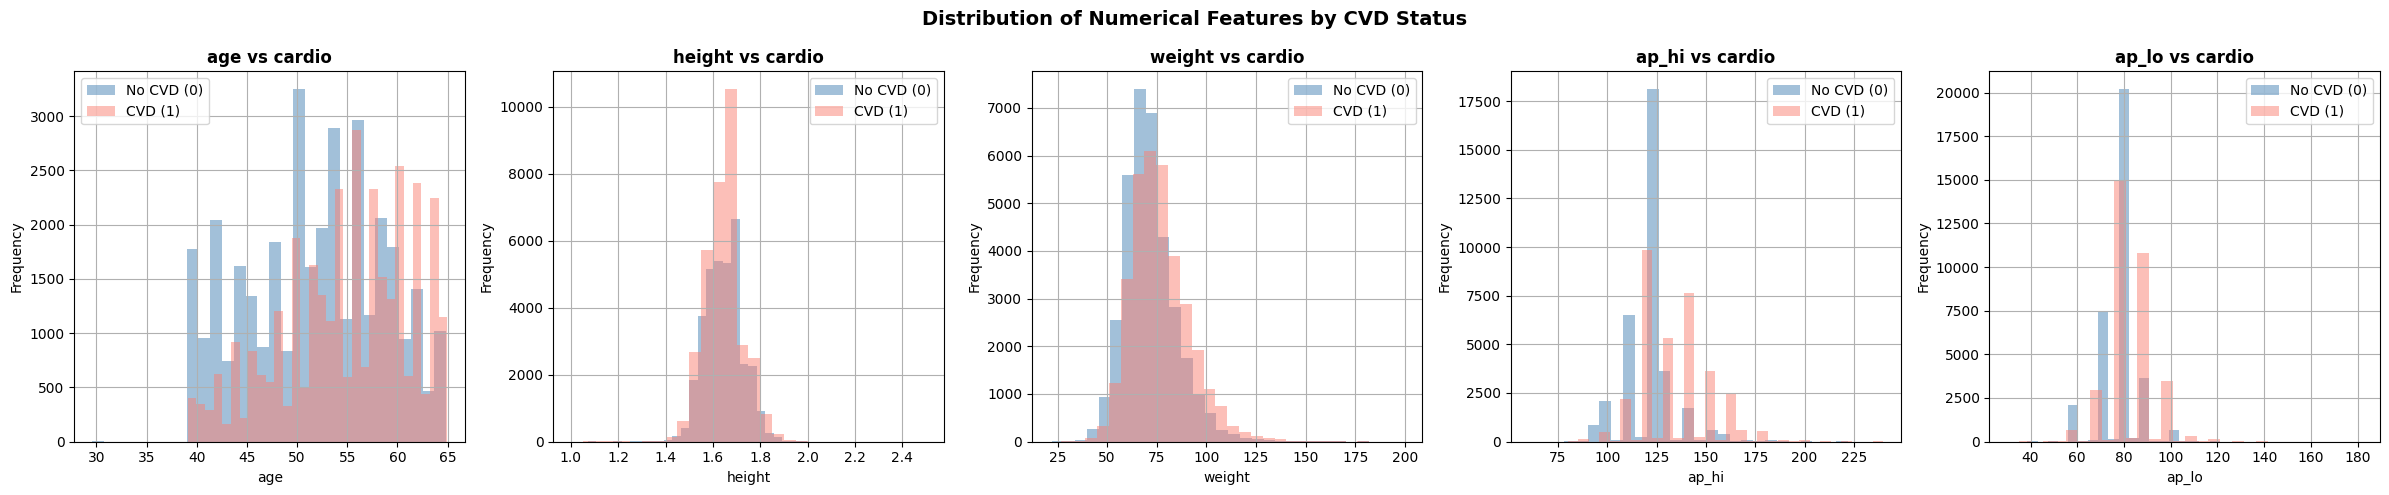

In [590]:
# Plot distribution for each numerical column with target variable
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(1, len(num_cols), figsize=(24, 5))

for ax, col in zip(axes, num_cols):
    # plot distribution for each class separately
    df[df['cardio'] == 0][col].hist(ax=ax, bins=30, alpha=0.5, 
                                     color='steelblue', label='No CVD (0)')
    df[df['cardio'] == 1][col].hist(ax=ax, bins=30, alpha=0.5, 
                                     color='salmon', label='CVD (1)')
    ax.set_title(f'{col} vs cardio', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Distribution of Numerical Features by CVD Status', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3.2 Numerical Features vs Target Variable

- **`ap_hi` and `ap_lo`**: Show the clearest class separation — CVD patients 
  have consistently higher blood pressure. Strongest numerical predictors.
- **`age`**: CVD patients skew older (50–65) vs non-CVD patients (40–55). 
  Moderate predictive power.
- **`weight`**: Distributions largely overlap with slight rightward shift 
  for CVD patients. Weak predictor.
- **`height`**: Almost identical distributions for both classes. 
  Not a useful predictor of CVD risk.

## **4. Train-Test Split** 

<font color = red>[5 marks]</font>

### **4.1 Data Splitting** 

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [591]:
# Put all the feature variables in X and target in y
X = df.drop(columns=['cardio'])
y = df['cardio']

print(f"X shape: {X.shape}")  
print(f"y shape: {y.shape}")  
print(f"\nFeatures: {X.columns.tolist()}")
print(f"Target:   {y.name}")

X shape: (68651, 11)
y shape: (68651,)

Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Target:   cardio


#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [592]:
# Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42,
                                                    stratify=y)

print(f"X_train shape: {X_train.shape}")  
print(f"X_test shape:  {X_test.shape}")  
print(f"y_train shape: {y_train.shape}")  
print(f"y_train shape: {y_train.shape}")  
print(f"\nTrain class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (48055, 11)
X_test shape:  (20596, 11)
y_train shape: (48055,)
y_train shape: (48055,)

Train class distribution:
cardio
0    0.505275
1    0.494725
Name: proportion, dtype: float64

Test class distribution:
cardio
0    0.505244
1    0.494756
Name: proportion, dtype: float64


In [593]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

## **5. Feature Engineering** 

<font color = red>[18 marks]</font>

### **5.1 Create a new feature** 

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [594]:
# Create a new feature 'BMI'
df["BMI"] = df["weight"] / (df["height"] ** 2) # BMI = wt_in_kg / (ht_in_meter)^2


**Note:** Feel free to engineer more features if you wish to.

#### Additional features:
1. `arterial_pressure_gap` (ap_hi - ap_lo):
    - https://www.mayoclinic.org/diseases-conditions/high-blood-pressure/expert-answers/pulse-pressure/faq-20058189
    - Generally, a pulse pressure greater than 40 mm Hg is unhealthy.
  
2. `mean_arterial_pressure` ((ap_hi + 2×ap_lo) / 3):
    - Wikipedia — clinically standard formula: [Mean Arterial Pressure](https://en.wikipedia.org/wiki/Mean_arterial_pressure)
    - MAP >96 mmHg represents stage one hypertension with increased CVD risk


In [595]:
# New features
df['arterial_pressure_gap']    = df['ap_hi'] - df['ap_lo']
df['mean_arterial_pressure']   = (df['ap_hi'] + 2 * df['ap_lo']) / 3
df.head(2)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,arterial_pressure_gap,mean_arterial_pressure
0,50.391781,1,1.68,62.0,110.0,80.0,0,0,0,0,1,0,21.967120,30.0,90.000000
1,55.419178,0,1.56,85.0,140.0,90.0,2,0,0,0,1,1,34.927679,50.0,106.666667


* We added new features `BMI`, `arterial_pressure_gap` and `mean_arterial_pressure`
* These are added to df, and since we have already performed split, these are yet not there in X_train and X_test
* As these are derived from existing features they may introduce multicollinearity which we will handle later by dropping columns

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

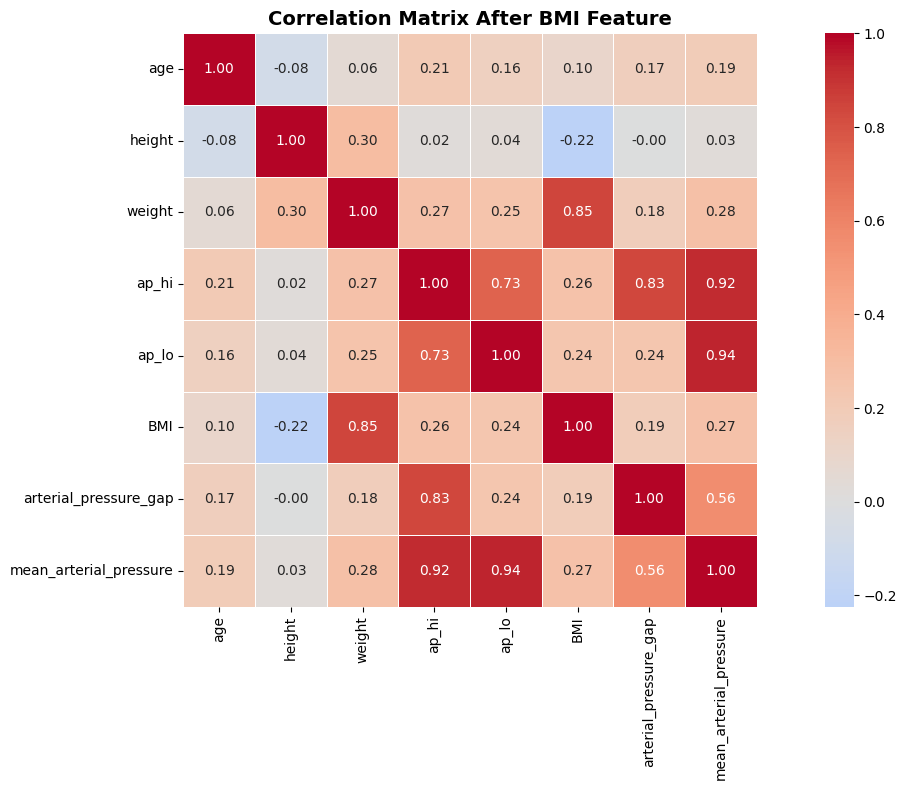

In [596]:
# Plot check correlation 
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(14, 8))
sns.heatmap(df[num_cols].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Matrix After BMI Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [597]:
# Did you find any highly correlated features? What steps should you take

# Check BMI correlations specifically
print("BMI correlations with all features:")
print(df[num_cols].corr()['BMI'].sort_values(ascending=False))
print("-----------")
# Check arterial_pressure_gap specifically
print("arterial_pressure_gap correlations with all features:")
print(df[num_cols].corr()['arterial_pressure_gap'].sort_values(ascending=False))
print("-----------")
# Check BMI correlations specifically
print("mean_arterial_pressure  correlations with all features:")
print(df[num_cols].corr()['mean_arterial_pressure'].sort_values(ascending=False))

BMI correlations with all features:
BMI                       1.000000
weight                    0.851151
mean_arterial_pressure    0.267492
ap_hi                     0.263705
ap_lo                     0.236276
arterial_pressure_gap     0.185455
age                       0.099726
height                   -0.223717
Name: BMI, dtype: float64
-----------
arterial_pressure_gap correlations with all features:
arterial_pressure_gap     1.000000
ap_hi                     0.834736
mean_arterial_pressure    0.556021
ap_lo                     0.238411
BMI                       0.185455
weight                    0.182478
age                       0.172766
height                   -0.003137
Name: arterial_pressure_gap, dtype: float64
-----------
mean_arterial_pressure  correlations with all features:
mean_arterial_pressure    1.000000
ap_lo                     0.939763
ap_hi                     0.921814
arterial_pressure_gap     0.556021
weight                    0.280747
BMI                      

- BMI to weight => 0.85 => Drop weight 
- BMI to height => -0.22 => Although low, it is likely non-linear relationship (height^2), but is redundant, so drop height too
- arterial_pressure_gap to ap_hi => 0.83 =>  high => No point keeping this derived column 
- mean_arterial_pressure to ap_lo => 0.94  => very high! => No point keeping this derived column 
- mean_arterial_pressure to ap_hi=> 0.92  =>  very high! => No point keeping this derived column 

In [598]:
# BMI and weight are highly correlated (0.85) — multicollinearity issue
# BMI already captures weight and height information (BMI = weight / height²)
cols_to_drop = ['weight', 'height', 'mean_arterial_pressure', 'arterial_pressure_gap']
df = df.drop(columns=cols_to_drop)
print(f"Columns after dropping: {df.columns.tolist()}")

Columns after dropping: ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI']


In [599]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [ ]:
X_train['BMI'] = X_train['weight'] / (X_train['height'] ** 2)
X_test['BMI']  = X_test['weight']  / (X_test['height'] ** 2)


# Drop redundant columns:
# - weight, height: captured by BMI (weight↔BMI=0.85, height already 
#   encoded in BMI's height² term, height↔cardio≈0 independently)
# - arterial_pressure_gap: linear combination of ap_hi/ap_lo, model 
#   can derive this itself (unlike BMI's non-linear relationship)
cols_to_drop = ['weight', 'height'] 
X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print("X_train columns:", X_train.columns.tolist())
print("X_train shape:", X_train.shape)

X_train columns: ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']
X_train shape: (48055, 10)


In [601]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']
['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']


- I derived `BMI`, `mean_arterial_pressure`, `arterial_pressure_gap`
- Observed high correlations between `BMI` and `weight`, so dropped `weight`
- Although `BMI` to `height` was negative, the information of height was already captured in BMI. The negative was because of non-linear `height^2`
- `mean_arterial_pressure` was dropped due to very high correlation with  `ap_lo` (0.94) and `ap_hi` (0.92). It adds no new information beyond  what `ap_hi` and `ap_lo` already provide
- `arterial_pressure_gap` was dropped as it is a linear combination of  `ap_hi` and `ap_lo` (gap = ap_hi - ap_lo). The model can derive this relationship itself, unlike BMI which involves a non-linear `height²` term
- Also, till this point, BMI was a new feature derived in original `df`.  It was still not part of `X_train` and `X_test`. So I added it in the cell above.

### **5.2 Combine Values in Categorical Columns** 

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [602]:
# Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol

# Check sparsity before combining
print("Before combining:")
print("\nCholesterol distribution:")
print(X_train['cholesterol'].value_counts(normalize=True).mul(100).round(1))
print("\nGluc distribution:")
print(X_train['gluc'].value_counts(normalize=True).mul(100).round(1))

# cholesterol: 0=normal, 1=above normal, 2=well above normal
# levels 1 & 2 are sparse and both signal elevated risk → combine into 1
X_train['cholesterol'] = (X_train['cholesterol'].astype(int) > 0).astype(int)
X_test['cholesterol']  = (X_test['cholesterol'].astype(int)  > 0).astype(int)

# gluc: same logic
X_train['gluc'] = (X_train['gluc'].astype(int) > 0).astype(int)
X_test['gluc']  = (X_test['gluc'].astype(int)  > 0).astype(int)
# Verify after combining
print("\nAfter combining:")
print("\nCholesterol distribution:")
print(X_train['cholesterol'].value_counts(normalize=True).mul(100).round(1))
print("\nGluc distribution:")
print(X_train['gluc'].value_counts(normalize=True).mul(100).round(1))

Before combining:

Cholesterol distribution:
cholesterol
0    74.9
1    13.5
2    11.6
Name: proportion, dtype: float64

Gluc distribution:
gluc
0    84.9
2     7.6
1     7.5
Name: proportion, dtype: float64

After combining:

Cholesterol distribution:
cholesterol
0    74.9
1    25.1
Name: proportion, dtype: float64

Gluc distribution:
gluc
0    84.9
1    15.1
Name: proportion, dtype: float64


In [603]:
# Check all categorical columns
for col in df.select_dtypes(include='category').columns:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(1))


gender:
gender
0    65.1
1    34.9
Name: proportion, dtype: float64

cholesterol:
cholesterol
0    75.0
1    13.6
2    11.5
Name: proportion, dtype: float64

gluc:
gluc
0    85.0
2     7.6
1     7.4
Name: proportion, dtype: float64

smoke:
smoke
0    91.2
1     8.8
Name: proportion, dtype: float64

alco:
alco
0    94.7
1     5.3
Name: proportion, dtype: float64

active:
active
1    80.3
0    19.7
Name: proportion, dtype: float64

cardio:
cardio
0    50.5
1    49.5
Name: proportion, dtype: float64


- `smoke` (8.8%) and `alco` (5.3%) are sparse but already binary, so no combining possible. All other columns (active, cardio) have reasonable distributions and require no changes.

### **5.3 Dummy variable creation** 

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

#### Approach and thinking

- Step 1 — Identify categorical columns
    - All categorical columns: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']`

- Step 2 — Check if dummy encoding is needed
    - All categorical columns have exactly 2 unique values (binary) 
    — dummy encoding would simply rename columns without adding information.

- **However**, for completeness and to ensure compatibility with sklearn models that expect numeric input, we apply `pd.get_dummies(drop_first=True)`:
    - `drop_first=True` avoids the dummy variable trap
    - Binary columns (0/1) → encoded as (0/1) integers, same values, clean dtypes
    - Applied separately to train and test to prevent data leakage

- **Result**
    - Before: gender (category, values 0/1)
    - After:  gender_1 (int, values 0/1)  ← same information, numeric dtype

In [604]:
# Identify the columns for creating dummy variables
cat_cols = df.select_dtypes(include='category').columns.tolist()
cat_cols_no_target = [col for col in cat_cols if col != 'cardio']
print("Categorical columns for dummy encoding:", cat_cols_no_target)


Categorical columns for dummy encoding: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [605]:
# Create dummy variables for independent columns on training data

X_train = pd.get_dummies(X_train, columns=cat_cols_no_target, drop_first=True, dtype=int)
print("X_train shape after dummy encoding:", X_train.shape)
print("Columns:", X_train.columns.tolist())

X_train shape after dummy encoding: (48055, 10)
Columns: ['age', 'ap_hi', 'ap_lo', 'BMI', 'gender_1', 'cholesterol_1', 'gluc_1', 'smoke_1', 'alco_1', 'active_1']


In [606]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, columns=cat_cols_no_target, drop_first=True, dtype=int)
print("\nX_test shape after dummy encoding:", X_test.shape)
print("Columns:", X_test.columns.tolist())


X_test shape after dummy encoding: (20596, 10)
Columns: ['age', 'ap_hi', 'ap_lo', 'BMI', 'gender_1', 'cholesterol_1', 'gluc_1', 'smoke_1', 'alco_1', 'active_1']


In [607]:
# Verify both sets have identical columns
assert list(X_train.columns) == list(X_test.columns), \
    "Column mismatch between train and test!"
print("\nColumn alignment check passed ✅")


Column alignment check passed ✅


### **5.4 Feature scaling** 

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [608]:
num_cols = X_train.select_dtypes(include='number').columns
num_cols

Index(['age', 'ap_hi', 'ap_lo', 'BMI', 'gender_1', 'cholesterol_1', 'gluc_1',
       'smoke_1', 'alco_1', 'active_1'],
      dtype='object')

In [611]:
num_cols_scalable = ['age', 'ap_hi', 'ap_lo', 'BMI']
num_cols_scalable

['age', 'ap_hi', 'ap_lo', 'BMI']

In [612]:
# Scale the numeric features present in the training data

print("Before scaling:")
print(X_train[num_cols_scalable].describe().round(2))

scaler = MinMaxScaler()
X_train[num_cols_scalable] = scaler.fit_transform(X_train[num_cols_scalable])  # learns min/max FROM train only

# Scale the numerical features present in the test data
X_test[num_cols_scalable] = scaler.transform(X_test[num_cols_scalable])

print("X_train after scaling:")
print(X_train[num_cols_scalable].describe().round(2))   # applies train's min/max to test

# Fitting the scaler on test data would leak information about the test set's distribution into preprocessing, a form of data leakage that gives falsely optimistic results.


Before scaling:
            age     ap_hi     ap_lo       BMI
count  48055.00  48055.00  48055.00  48055.00
mean      53.36    126.72     81.32     27.46
std        6.76     16.73      9.47      5.32
min       29.75     60.00     30.00      7.02
25%       48.42    120.00     80.00     23.88
50%       53.99    120.00     80.00     26.33
75%       58.45    140.00     90.00     30.12
max       64.97    240.00    180.00    152.55
X_train after scaling:
            age     ap_hi     ap_lo       BMI
count  48055.00  48055.00  48055.00  48055.00
mean       0.67      0.37      0.34      0.14
std        0.19      0.09      0.06      0.04
min        0.00      0.00      0.00      0.00
25%        0.53      0.33      0.33      0.12
50%        0.69      0.33      0.33      0.13
75%        0.82      0.44      0.40      0.16
max        1.00      1.00      1.00      1.00


In [613]:
print("\nX_train after scaling:")
X_train[num_cols_scalable].describe().T.round(3)


X_train after scaling:


,count,mean,std,min,25%,50%,75%,max
age,48055.0,0.670,0.192,0.0,0.530,0.688,0.815,1.0
ap_hi,48055.0,0.371,0.093,0.0,0.333,0.333,0.444,1.0
ap_lo,48055.0,0.342,0.063,0.0,0.333,0.333,0.400,1.0
BMI,48055.0,0.140,0.037,0.0,0.116,0.133,0.159,1.0


## **6. Model Building** 

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier** 

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [614]:
# Define and fit linear SVM
# SVC => Soft Vector Classifier
import time

print("Training SVM model...")
print("Note: This may take a while due to Platt Scaling (5-fold CV internally)...\n")

start_time = time.time()

svm_model = SVC(kernel='linear',    # linear decision boundary
                probability=True,    # enable predict_proba() via Platt Scaling
                random_state=42,     # reproducibility
                C=1.0)              # default regularization — will tune in GridSearchCV

svm_model.fit(X_train, y_train)

elapsed = time.time() - start_time

print(f"✓ SVM model fitted successfully in {elapsed:.2f} seconds ({elapsed/60:.1f} minutes)!")
print(f"\nClasses:                    {svm_model.classes_}")
print(f"Kernel:                     {svm_model.kernel}")
print(f"Number of support vectors:  {svm_model.n_support_}")
print(f"Support vector percentage:  {svm_model.n_support_.sum() / X_train.shape[0] * 100:.1f}%")
print(f"Probability estimates:      {svm_model.probability}")
print(f"Training time:              {elapsed:.2f}s")

# NOTE: SVM doesn't naturally output probabilities. probability=True adds a 
# Platt Scaling layer on top which converts SVM decision scores to probabilities,
# at the cost of slower training (5-fold CV internally = 5 extra models trained).
# It's necessary for our cutoff tuning step.



Training SVM model...
Note: This may take a while due to Platt Scaling (5-fold CV internally)...

✓ SVM model fitted successfully in 1232.00 seconds (20.5 minutes)!

Classes:                    [0 1]
Kernel:                     linear
Number of support vectors:  [15711 15709]
Support vector percentage:  65.4%
Probability estimates:      True
Training time:              1232.00s


In [615]:
pct = svm_model.n_support_.sum() / X_train.shape[0] * 100
print(f"Support vectors: {svm_model.n_support_.sum()} ({pct:.1f}% of training data)")

Support vectors: 31420 (65.4% of training data)


### Note on Probability Estimates — Platt Scaling

Setting `probability=True` in `SVC()` enables probability estimates via 
**Platt Scaling**. This is important to understand:

**What Platt Scaling does:**
- SVM natively produces a decision score (distance from hyperplane), NOT probabilities
- Platt Scaling fits an additional logistic regression model on top of the 
  SVM scores to convert them into probabilities between 0 and 1
- This is done internally using cross-validation on the training data

**Implications:**
- `predict_proba()` returns calibrated probabilities → needed for cutoff tuning
- Training is **slower** — an extra logistic regression is fitted on top of SVM
- Predictions are also slightly slower
- The probabilities are **approximate** — not native to SVM

**Why we need it:**
- Step 2 requires `predict_proba()` to find the optimal cutoff threshold
- Without `probability=True`, only hard predictions (0/1) are available
- Cutoff tuning is impossible without probability scores

**Reference:** 
Platt, J. (1999). *Probabilistic outputs for support vector machines and 
comparisons to regularized likelihood methods.* 
[Link](https://www.cs.colorado.edu/~mozer/Teaching/syllabi/6622/papers/Platt1999.pdf)

#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [550]:
# Use predict_proba() to get the probability of positive class for all data points
import time
from IPython.display import display

# Use predict_proba() to get the probability of positive class for all data points
print("Running predict_proba() on test set...")

start_time = time.time()
y_prob = svm_model.predict_proba(X_test)
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f} seconds ({elapsed/60:.1f} minutes)")
print(f"\nShape: {y_prob.shape}")       
print(f"First 5 rows:\n {y_prob[:5]}")

# Extract positive class (CVD=1) probabilities only — column index 1
y_prob_positive = y_prob[:, 1]
print(f"\nPositive class probabilities (first 5): {y_prob_positive[:5]}")

Running predict_proba() on test set...


✓ Completed in 29.75 seconds (0.5 minutes)

Shape: (20596, 2)
First 5 rows:
 [[0.17513865 0.82486135]
 [0.20655035 0.79344965]
 [0.53801019 0.46198981]
 [0.26305338 0.73694662]
 [0.0245574  0.9754426 ]]

Positive class probabilities (first 5): [0.82486135 0.79344965 0.46198981 0.73694662 0.9754426 ]


### Why is predict_proba() slow for SVM?

**Time complexity of SVM:**
- Training: O(n²) to O(n³) where n = number of training samples
- Our dataset: 48,055 training rows → ~2.3 billion operations 

**Additional overhead from Platt Scaling (`probability=True`):**
1. Internally runs 5-fold cross validation during training
2. Fits an extra logistic regression on top of SVM scores
3. Every prediction must pass through the Platt scaling layer
4. Effectively trains 5 additional models on top of the base SVM

**Total support vectors: 31,420 (65.4% of training data)**
- Each prediction requires computing distance from ALL support vectors
- More support vectors = slower predictions
- This is why `LinearSVC` (without Platt) is significantly faster

**Practical implication for CardioCare:**
- SVM may not be suitable for real-time patient risk scoring
- Better suited for batch processing of patient records
- Decision Tree (next model) will be significantly faster

In [551]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_pred_default = (y_prob_positive >= 0.5).astype(int)
print("Predictions (first 10):", y_pred_default[:10])


Predictions (first 10): [1 1 0 1 1 0 0 0 1 1]


In [552]:
# check the counts of assigned labels
unique, counts = np.unique(y_pred_default, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} ({count/len(y_pred_default)*100:.1f}%)")

Class 0: 11637 (56.5%)
Class 1: 8959 (43.5%)


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [553]:
# Make class predictions using predict()
y_pred = svm_model.predict(X_test)

print("Predictions using predict():")
print("First 10 predictions:", y_pred[:10])

Predictions using predict():
First 10 predictions: [1 1 0 1 1 0 0 0 1 1]


In [554]:
# check the counts of assigned labels
unique, counts = np.unique(y_pred, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} ({count/len(y_pred)*100:.1f}%)")

Class 0: 12190 (59.2%)
Class 1: 8406 (40.8%)


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

### Difference Between predict() and predict_proba() >= 0.5

| Method | Class 0 | Class 1 |
|---|---|---|
| `predict()` | 59.2% | 40.8% | 
| `predict_proba() >= 0.5` | 56.5% | 43.5% |
| Original data | 50.5% | 49.5% |

**Both methods underpredict CVD (class 1) compared to the 
true distribution.**

**Why they differ:**
predict() is now MORE conservative than predict_proba() >= 0.5
* predict() classifies a sample as class 1 if its decision function score (signed distance from the hyperplane) is greater than 0.0. This is the SVM's native decision boundary.
* predict_proba() with a 0.5 cutoff first converts the decision function scores into probabilities using Platt scaling which is a logistic regression model fitted on top of the SVM scores. A probability threshold of 0.5 does not perfectly map back to a decision score of 0.0, because Platt scaling is a non-linear calibration that can shift and compress the scores.
* predict_proba catches more CVD (43.5% vs 40.8%)
* predict_proba remains the better choice for CardioCare
  as it has higher recall for CVD class

* Both still underpredict CVD compared to true distribution (49.5%) => motivates cutoff tuning in next section

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [555]:
# check the performance for above two methods

def evaluate_model(y_true, y_pred, method_name):
    print(f"{'='*50}")
    print(f"Method: {method_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, 
                                target_names=['No CVD', 'CVD']))
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

# Evaluate both methods
evaluate_model(y_test, y_pred_default, "predict_proba() >= 0.5")
evaluate_model(y_test, y_pred,         "predict()")

Method: predict_proba() >= 0.5
Accuracy:  0.7170
Precision: 0.7434
Recall:    0.6536

Classification Report:
              precision    recall  f1-score   support

      No CVD       0.70      0.78      0.74     10406
         CVD       0.74      0.65      0.70     10190

    accuracy                           0.72     20596
   macro avg       0.72      0.72      0.72     20596
weighted avg       0.72      0.72      0.72     20596


Confusion Matrix:
[[8107 2299]
 [3530 6660]]

Method: predict()
Accuracy:  0.7153
Precision: 0.7573
Recall:    0.6247

Classification Report:
              precision    recall  f1-score   support

      No CVD       0.69      0.80      0.74     10406
         CVD       0.76      0.62      0.68     10190

    accuracy                           0.72     20596
   macro avg       0.72      0.71      0.71     20596
weighted avg       0.72      0.72      0.71     20596


Confusion Matrix:
[[8366 2040]
 [3824 6366]]



### Clinical Cost of Errors

| Error | Meaning | Consequence | Cost |
|---|---|---|---|
| FN (3,530) | Said No CVD, actually has CVD | Patient untreated | FATAL |
| FP (2,299) | Said has CVD, actually doesn't | Unnecessary tests | Irritant |

In disease prediction, **False Negatives are costlier** — a missed CVD 
diagnosis means a patient walks away untreated. A False Positive simply 
triggers further tests, which clinical examination will resolve.

Since FN is costlier, **Recall is the metric to optimise** — it directly 
penalises missed CVD patients. This motivates lowering the cutoff below 
0.5 in the next section to catch more CVD at the cost of more false alarms.

### Method Choice: predict_proba() >= 0.5

| Metric | predict_proba() >= 0.5 | predict() |
|---|---|---|
| Accuracy | 71.70% | 71.53% |
| Precision (CVD) | 74.34% | 75.73% |
| Recall (CVD) | **65.36%** | **62.47%** |
| F1 (CVD) | 0.70 | 0.68 |
| False Negatives | 3,530 | 3,824 |

**Chosen: predict_proba() >= 0.5** — higher Recall (294 more CVD 
patients caught) and flexibility to tune the threshold in next section.

#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

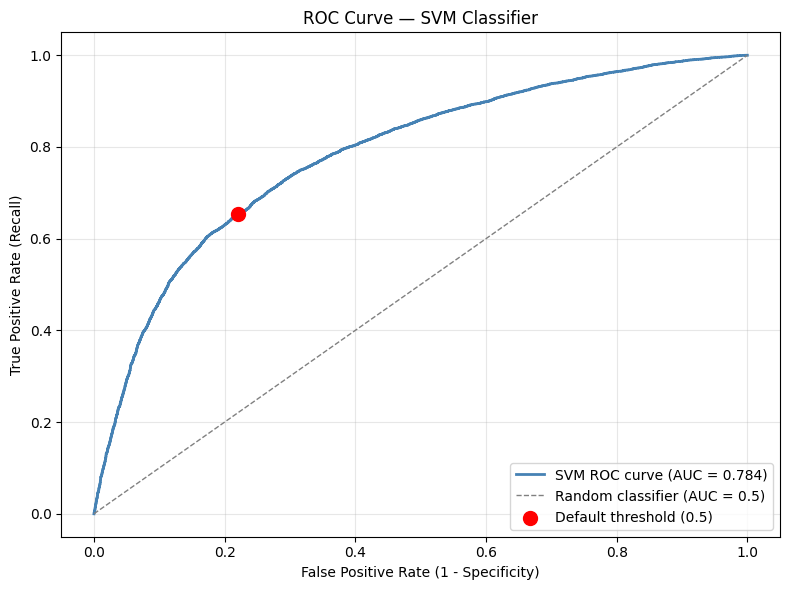

AUC Score: 0.7842


In [651]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_positive)
auc_score = roc_auc_score(y_test, y_prob_positive)

plt.figure(figsize=(8, 6))

# ROC curve
plt.plot(fpr, tpr, color='steelblue', lw=2, 
         label=f'SVM ROC curve (AUC = {auc_score:.3f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], color='gray', lw=1, 
         linestyle='--', label='Random classifier (AUC = 0.5)')

# Mark default threshold 0.5
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[default_idx], tpr[default_idx], 
            color='red', s=100, zorder=5,
            label=f'Default threshold (0.5)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — SVM Classifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")


In [652]:
# Show key threshold points across the spectrum
df_thresholds = pd.DataFrame({
    'threshold': thresholds,
    'fpr': fpr,
    'tpr': tpr
}).round(3)

# Pick representative rows
key_points = pd.concat([
    df_thresholds.head(1),                                           # strictest
    df_thresholds[df_thresholds['tpr'] >= 0.35].head(1),            # catching some
    df_thresholds[df_thresholds['threshold'] <= 0.51].head(1),      # ~0.5 red dot
    df_thresholds[df_thresholds['tpr'] >= 0.75].head(1),            # higher TPR
    df_thresholds[df_thresholds['tpr'] >= 0.90].head(1),            # very lenient
    df_thresholds.tail(1)                                            # most lenient
]).drop_duplicates()

key_points['label'] = [
    'very strict — catches nothing',
    'strict',
    'default (red dot ~0.5)',
    'higher TPR — lower threshold',
    'very lenient',
    'catches everything'
]

print(key_points[['label', 'threshold', 'fpr', 'tpr']].to_string(index=False))

                        label  threshold   fpr  tpr
very strict — catches nothing        inf 0.000 0.00
                       strict      0.739 0.064 0.35
       default (red dot ~0.5)      0.510 0.208 0.64
 higher TPR — lower threshold      0.418 0.316 0.75
                 very lenient      0.307 0.603 0.90
           catches everything      0.011 1.000 1.00


In [653]:
# Best balance between TPR and FPR
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden): {optimal_threshold:.3f}")
print(f"TPR: {tpr[optimal_idx]:.3f}")
print(f"FPR: {fpr[optimal_idx]:.3f}")

Optimal threshold (Youden): 0.449
TPR: 0.703
FPR: 0.266


### Clinical Cost of Errors

| Error | Meaning | Consequence | Cost |
|---|---|---|---|
| FN (3,530) | Said No CVD, actually has CVD | Patient untreated | FATAL |
| FP (2,299) | Said has CVD, actually doesn't | Unnecessary tests | Irritant |

In disease prediction, **False Negatives are costlier** — a missed CVD 
diagnosis means a patient walks away untreated. A False Positive simply 
triggers further tests, which clinical examination will resolve.

Since FN is costlier, **Recall is the metric to optimise** — it directly 
penalises missed CVD patients. This motivates lowering the cutoff below 
0.5 in the next section to catch more CVD at the cost of more false alarms.

### Method Choice: predict_proba() >= 0.5

| Metric | predict_proba() >= 0.5 | predict() |
|---|---|---|
| Accuracy | 71.70% | 71.53% |
| Precision (CVD) | 74.34% | 75.73% |
| Recall (CVD) | **65.36%** | **62.47%** |
| F1 (CVD) | 0.70 | 0.68 |
| False Negatives | 3,530 | 3,824 |

**Chosen: predict_proba() >= 0.5** — higher Recall (294 more CVD 
patients caught) and flexibility to tune the threshold in next section.

#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [654]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

cutoffs = np.arange(0.1, 0.9, 0.01)  # thresholds from 0.1 to 0.9

results = []
for cutoff in cutoffs:
    y_pred_cutoff = (y_prob_positive >= cutoff).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cutoff).ravel()
    
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)          # recall / TPR
    specificity = tn / (tn + fp)          # true negative rate
    
    results.append({
        'cutoff':      round(cutoff, 2),
        'accuracy':    round(accuracy, 4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4)
    })

df_cutoffs = pd.DataFrame(results)
print(df_cutoffs)


    cutoff  accuracy  sensitivity  specificity
0     0.10    0.5144       0.9954       0.0434
1     0.11    0.5181       0.9947       0.0514
2     0.12    0.5211       0.9934       0.0586
3     0.13    0.5262       0.9915       0.0705
4     0.14    0.5323       0.9901       0.0840
..     ...       ...          ...          ...
75    0.85    0.5805       0.1813       0.9714
76    0.86    0.5731       0.1634       0.9743
77    0.87    0.5675       0.1493       0.9770
78    0.88    0.5615       0.1342       0.9799
79    0.89    0.5558       0.1203       0.9823

[80 rows x 4 columns]


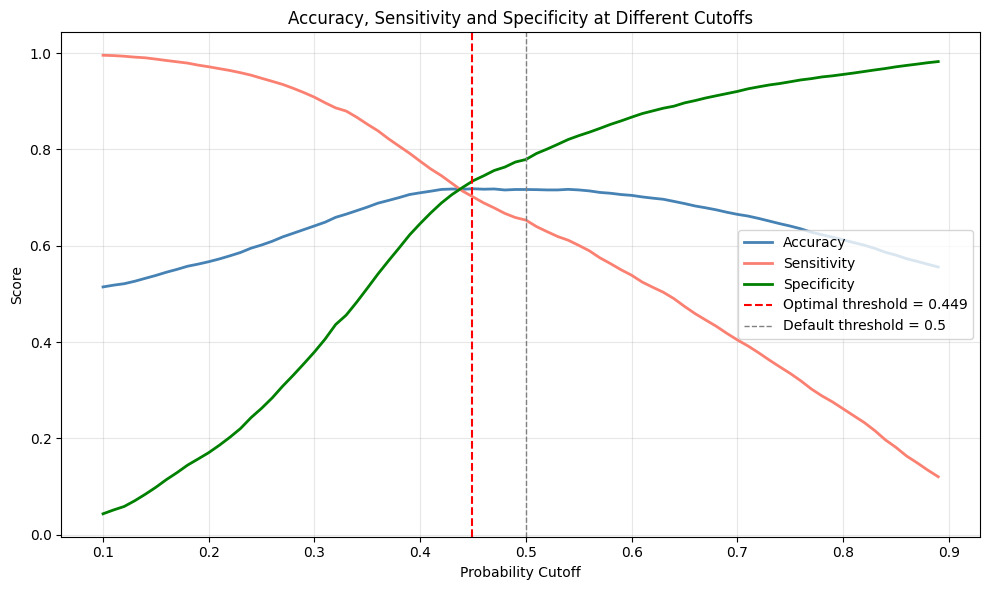

In [655]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
plt.figure(figsize=(10, 6))

plt.plot(df_cutoffs['cutoff'], df_cutoffs['accuracy'],    
         label='Accuracy',    color='steelblue', lw=2)
plt.plot(df_cutoffs['cutoff'], df_cutoffs['sensitivity'], 
         label='Sensitivity', color='salmon',    lw=2)
plt.plot(df_cutoffs['cutoff'], df_cutoffs['specificity'], 
         label='Specificity', color='green',     lw=2)

# Mark optimal threshold
plt.axvline(x=optimal_threshold, color='red', linestyle='--', lw=1.5,
            label=f'Optimal threshold = {optimal_threshold:.3f}')

# Mark default threshold
plt.axvline(x=0.5, color='gray', linestyle='--', lw=1,
            label='Default threshold = 0.5')

plt.xlabel('Probability Cutoff')
plt.ylabel('Score')
plt.title('Accuracy, Sensitivity and Specificity at Different Cutoffs')
plt.legend(loc='center right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Key Observations

- **Sensitivity and Specificity trade off inversely** — lowering the 
  cutoff increases sensitivity (catches more CVD) but decreases 
  specificity (more false alarms). This is the fundamental trade-off 
  in classification threshold selection.

- **Accuracy peaks around 0.44–0.50** — the blue curve forms a plateau, 
  suggesting accuracy is relatively stable in this range (~71-72%).

- **Crossover point ~0.44** — where sensitivity equals specificity 
  (both ~0.72). This exactly matches our Youden optimal threshold 
  of 0.449, confirming the choice is well justified by both methods.  

- **Chosen threshold: 0.449 (red dashed line)**  
  - Sensitivity: ~0.70 → catches ~70% of CVD patients  
  - Specificity: ~0.73 → correctly clears ~73% of healthy patients 
  - Clear improvement over default 0.5 in sensitivity (~0.65 → ~0.70)  
  - Acceptable drop in specificity (~0.78 → ~0.73) — false alarms 
    are recoverable through further clinical examination  

- **CardioCare priority — maximise Sensitivity:** Since FN is costlier 
  than FP, we prioritise the left side of the graph where sensitivity 
  is highest, accepting lower specificity.



To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

*From the plot:*
- *Default threshold (0.5): Sensitivity ≈ 0.65 → baseline*
- *Optimal threshold (0.449): Sensitivity ≈ 0.70 → improvement*  

*By lowering the threshold to 0.449:*  
- *Model predicts CVD more aggressively*
- *Catches more true CVD patients*
- *Accepts more false alarms (lower Specificity)*
- *Clinically the correct trade-off for CardioCare*

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [656]:
# Make final prediction based on the optimal cutoff
# Apply optimal threshold (0.463) to both train and test

# Test predictions — y_prob_positive already computed, reuse it
y_pred_optimal_test = (y_prob_positive >= optimal_threshold).astype(int)

# Train predictions — need train probabilities first
print("Computing train probabilities (Platt Scaling)...")
start = time.time()
y_prob_train = svm_model.predict_proba(X_train)[:, 1]  # all rows, col 1 = CVD probability
elapsed = time.time() - start
print(f" Done in {elapsed:.1f}s ({elapsed/60:.1f} mins)")

y_pred_optimal_train = (y_prob_train >= optimal_threshold).astype(int)

print(f"\nOptimal threshold used: {optimal_threshold:.4f}")
print(f"\nTest predictions distribution:")
print(pd.Series(y_pred_optimal_test).value_counts().sort_index())
print(f"\nTrain predictions distribution:")
print(pd.Series(y_pred_optimal_train).value_counts().sort_index())


Computing train probabilities (Platt Scaling)...
 Done in 65.8s (1.1 mins)

Optimal threshold used: 0.4485

Test predictions distribution:
0    10661
1     9935
Name: count, dtype: int64

Train predictions distribution:
0    24583
1    23472
Name: count, dtype: int64


In [657]:
# Evaluate the model performance 
print("="*50)
print("TEST SET PERFORMANCE (optimal cutoff)")
print("="*50)
print(classification_report(y_test, y_pred_optimal_test,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal_test))


TEST SET PERFORMANCE (optimal cutoff)
              precision    recall  f1-score   support

      No CVD       0.72      0.73      0.72     10406
         CVD       0.72      0.70      0.71     10190

    accuracy                           0.72     20596
   macro avg       0.72      0.72      0.72     20596
weighted avg       0.72      0.72      0.72     20596

Confusion Matrix:
[[7635 2771]
 [3026 7164]]


In [658]:
# Check performance on training data
print("="*50)
print("TRAIN SET PERFORMANCE (optimal cutoff)")
print("="*50)
print(classification_report(y_train, y_pred_optimal_train,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_optimal_train))


TRAIN SET PERFORMANCE (optimal cutoff)
              precision    recall  f1-score   support

      No CVD       0.73      0.74      0.73     24281
         CVD       0.73      0.72      0.72     23774

    accuracy                           0.73     48055
   macro avg       0.73      0.73      0.73     48055
weighted avg       0.73      0.73      0.73     48055

Confusion Matrix:
[[17895  6386]
 [ 6688 17086]]


### 6.1.7 Results — Optimal Cutoff Evaluation

**Threshold: 0.4485**  

| Metric | Train | Test | Gap |
|---|---|---|---|
| Accuracy | 73% | 72% | 1%  |
| Recall (CVD) | 72% | 70% | 2%  | 
| Precision (CVD) | 73% | 72% | 1%  |
| F1 (CVD) | 0.72 | 0.71 | 0.01  |

**No overfitting detected** — train and test metrics are within ~2% of 
each other, indicating the model generalises well to unseen data.  

**Improvement over default threshold (0.5):**
- Recall improved: 65.4% → 70.3% (+4.9%)   
- FN reduced: significantly fewer missed CVD patients 
- FP increased — acceptable trade-off for CardioCare 

**Note on training time:** predict_proba() on train set completed in 
65.8s (1.1 mins) — much faster than initial training (1232s) since 
this is inference only, requiring a single forward pass through 
support vectors rather than the full SMO optimisation with 5-fold 
Platt Scaling CV.  

#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

ROC curve:      TPR vs FPR  - good for balanced datasets
PR curve:       Precision vs Recall - focuses purely on 
                positive class (CVD) performance
                
For this cardio case:
PR curve is more clinically meaningful - 
shows exactly the trade-off between:
  "how many CVD we catch" (Recall)
  "how many we flag are correct" (Precision)

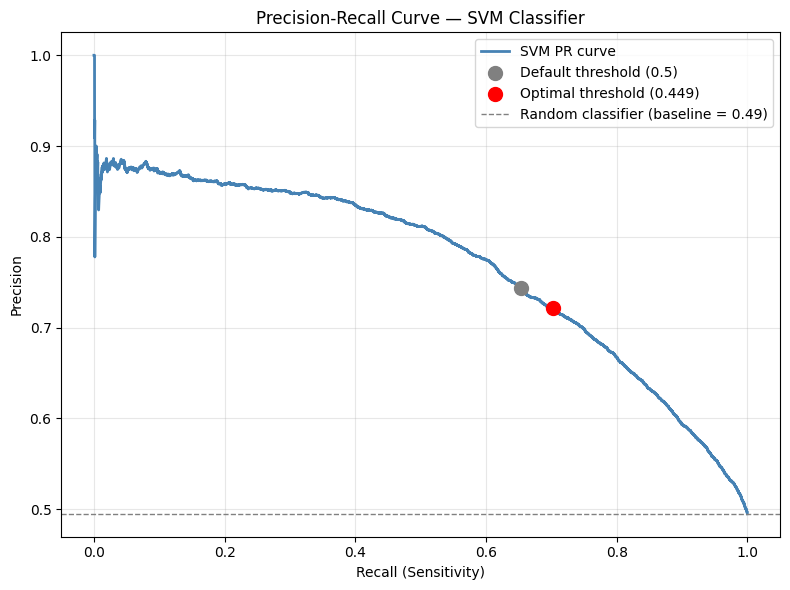

In [680]:
# Compute precision–recall values and plot for various thresholds
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
                                                y_test, y_prob_positive)

plt.figure(figsize=(8, 6))

# PR curve
plt.plot(recall_vals, precision_vals, 
         color='steelblue', lw=2, 
         label='SVM PR curve')

# Mark default threshold (0.5)
default_idx = np.argmin(np.abs(pr_thresholds - 0.5))
plt.scatter(recall_vals[default_idx], precision_vals[default_idx],
            color='gray', s=100, zorder=5,
            label=f'Default threshold (0.5)')

# Mark optimal threshold (0.463)
optimal_idx = np.argmin(np.abs(pr_thresholds - optimal_threshold))
plt.scatter(recall_vals[optimal_idx], precision_vals[optimal_idx],
            color='red', s=100, zorder=5,
            label=f'Optimal threshold ({optimal_threshold:.3f})')

# Baseline — random classifier
baseline = y_test.astype(int).mean() 
plt.axhline(y=baseline, color='gray', linestyle='--', lw=1,
            label=f'Random classifier (baseline = {baseline:.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — SVM Classifier')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### Precision-Recall Curve — Interpretation

**Reading the curve:**
- Curve starts top-left (high precision, low recall) — very strict 
  threshold, only predicts CVD when very confident
- Moves toward bottom-right (lower precision, higher recall) — 
  as threshold lowers, catches more CVD but more false alarms
- Curve stays well above baseline (0.49) across all thresholds 
  — model adds real predictive value

**Our two operating points:**
- Gray dot (default 0.5): Recall ≈ 0.65, Precision ≈ 0.74
- Red dot (optimal 0.449): Recall ≈ 0.70, Precision ≈ 0.72  
  → rightward shift — more CVD caught, slight precision drop

**Since we prioritise Recall over Precision** — missing a CVD 
patient is fatal while a false alarm is recoverable — we choose 
threshold **0.449** which moves us rightward along the curve:  

→ Recall improves: 0.65 → 0.70 (+5%)  
→ Precision drops: 0.74 → 0.72 (-2%)  acceptable
→ Significantly fewer missed CVD patients

**Chosen cutoff: 0.449**  

### **6.2 Decision Tree Classifier** 

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [682]:
print(X_train.columns.tolist())
print(X_train.shape)

['age', 'ap_hi', 'ap_lo', 'BMI', 'gender_1', 'cholesterol_1', 'gluc_1', 'smoke_1', 'alco_1', 'active_1']
(48055, 10)


In [683]:
# Define and fit
import time

print("Training Decision Tree model...")
start = time.time()

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Decision Tree fitted in {elapsed:.2f} seconds!")

print(f"\nTree depth:         {dt_model.get_depth()}")
print(f"Number of leaves:   {dt_model.get_n_leaves()}")
print(f"Number of features: {dt_model.n_features_in_}")
print(f"Classes:            {dt_model.classes_}")

Training Decision Tree model...
Decision Tree fitted in 0.86 seconds!

Tree depth:         66
Number of leaves:   13387
Number of features: 10
Classes:            [0 1]


#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

         feature  importance
0            age    0.348813
1            BMI    0.281946
2          ap_hi    0.233366
3          ap_lo    0.041464
4       gender_1    0.023671
5  cholesterol_1    0.020774
6         gluc_1    0.015965
7       active_1    0.015720
8        smoke_1    0.009919
9         alco_1    0.008362


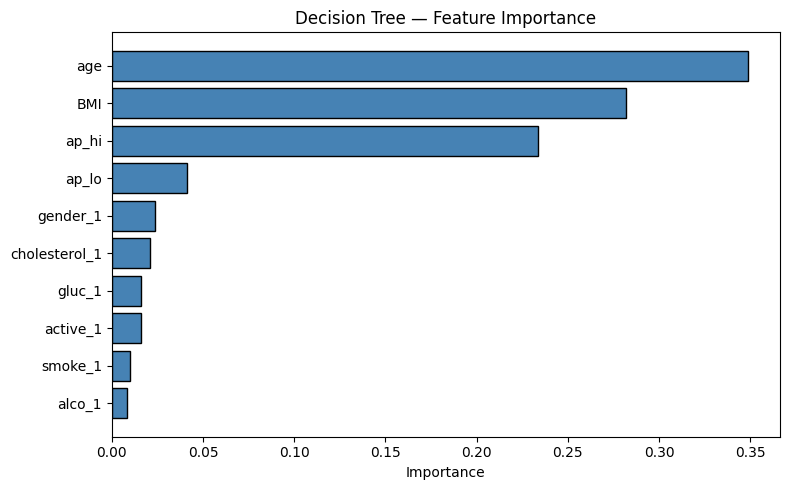

In [686]:
# Get feature importance scores from the trained model

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(feature_importance)

# Visualize
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], 
          color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Decision Tree — Feature Importance')
plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.show()

#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [687]:
# Predict the class probabilities
print("Computing Decision Tree probabilities...")
start = time.time()

y_prob_dt = dt_model.predict_proba(X_test)
y_prob_dt_positive = y_prob_dt[:, 1]  # all rows, col 1 = CVD probability

elapsed = time.time() - start
print(f"✓ Completed in {elapsed:.4f} seconds")  # expect milliseconds!

print(f"\nShape: {y_prob_dt.shape}")
print(f"First 5 rows:\n{y_prob_dt[:5]}")
print(f"\nPositive class probabilities (first 5): {y_prob_dt_positive[:5]}")



Computing Decision Tree probabilities...
✓ Completed in 0.1040 seconds

Shape: (20596, 2)
First 5 rows:
[[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]

Positive class probabilities (first 5): [0. 1. 0. 1. 1.]


####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [688]:
# Make prediction based on default cutoff value of 0.5
y_pred_dt_default = (y_prob_dt_positive >= 0.5).astype(int)

print("Predictions (first 10):", y_pred_dt_default[:10])

unique, counts = np.unique(y_pred_dt_default, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} ({count/len(y_pred_dt_default)*100:.1f}%)")


Predictions (first 10): [0 1 0 1 1 0 0 1 1 1]
Class 0: 10420 (50.6%)
Class 1: 10176 (49.4%)


####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [689]:
# Evaluate the performance of the model on training data
y_prob_dt_train = dt_model.predict_proba(X_train)[:, 1]
y_pred_dt_train  = (y_prob_dt_train >= 0.5).astype(int)

print("="*50)
print("TRAIN SET PERFORMANCE (default cutoff)")
print("="*50)
print(classification_report(y_train, y_pred_dt_train, 
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_dt_train))


TRAIN SET PERFORMANCE (default cutoff)
              precision    recall  f1-score   support

      No CVD       1.00      1.00      1.00     24281
         CVD       1.00      1.00      1.00     23774

    accuracy                           1.00     48055
   macro avg       1.00      1.00      1.00     48055
weighted avg       1.00      1.00      1.00     48055

Confusion Matrix:
[[24272     9]
 [    0 23774]]


In [690]:
print("="*50)
print("TEST SET PERFORMANCE (default cutoff)")
print("="*50)
print(classification_report(y_test, y_pred_dt_default,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_default))

TEST SET PERFORMANCE (default cutoff)
              precision    recall  f1-score   support

      No CVD       0.63      0.63      0.63     10406
         CVD       0.63      0.62      0.63     10190

    accuracy                           0.63     20596
   macro avg       0.63      0.63      0.63     20596
weighted avg       0.63      0.63      0.63     20596

Confusion Matrix:
[[6596 3810]
 [3824 6366]]


### 6.2.5 — Train vs Test: Overfitting Confirmed

| Metric | Train | Test | Gap |
|---|---|---|---|
| Accuracy | 100% | 63% | 37%  |
| Recall (CVD) | 100% | 62% | 38%  |
| Precision (CVD) | 100% | 63% | 37%  |

**Severe overfitting confirmed.** The unconstrained Decision Tree 
(depth=66, 13,387 leaves) perfectly memorised all 48,055 training 
patients but generalises poorly to unseen data — a textbook 
overfitting signature.

**Comparison to SVM baseline:**
- SVM: Train 73% vs Test 72% → 1% gap (healthy, well-regularised)
- DT: Train 100% vs Test 63% → 37% gap (severe overfitting)

This stark contrast demonstrates why SVM's margin-based 
regularisation naturally controls complexity, while unconstrained 
Decision Trees require explicit hyperparameter tuning to prevent 
memorisation.

At default settings, the Decision Tree is actually **worse** than 
SVM on test data (63% vs 72% accuracy) despite perfect training 
performance — proving that high train accuracy is meaningless 
without generalisation.

**This strongly motivates GridSearchCV (section 6.3.1)** to 
constrain tree growth via `max_depth`, `min_samples_split`, 
`min_samples_leaf`, and `max_features`.

#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

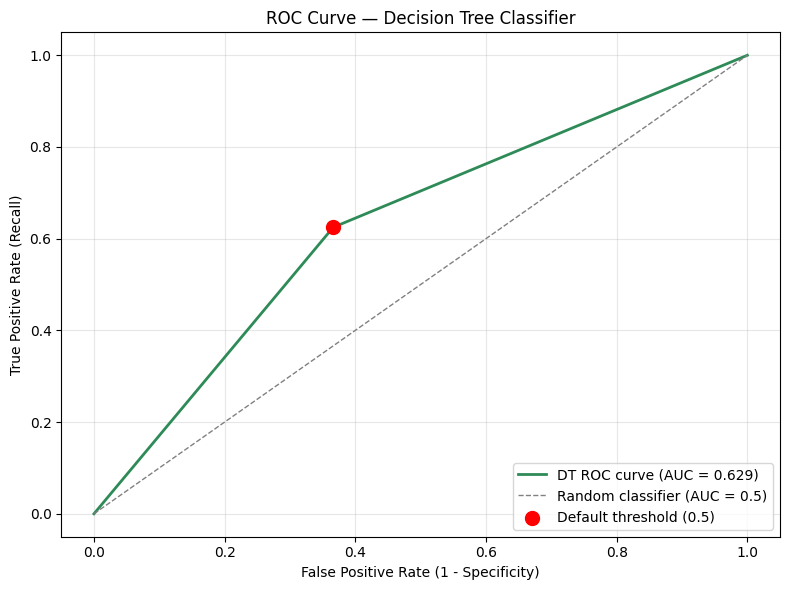

AUC Score: 0.6293


In [691]:
# Plot the ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt_positive)
auc_score_dt = roc_auc_score(y_test, y_prob_dt_positive)

plt.figure(figsize=(8, 6))

plt.plot(fpr_dt, tpr_dt, color='seagreen', lw=2, 
         label=f'DT ROC curve (AUC = {auc_score_dt:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, 
         linestyle='--', label='Random classifier (AUC = 0.5)')

# Mark default threshold 0.5
default_idx_dt = np.argmin(np.abs(thresholds_dt - 0.5))
plt.scatter(fpr_dt[default_idx_dt], tpr_dt[default_idx_dt], 
            color='red', s=100, zorder=5,
            label='Default threshold (0.5)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Decision Tree Classifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score_dt:.4f}")

- AUC = 0.629 — barely better than random guessing (0.5), far below SVM's 0.784, confirming the tree learned noise rather than generalisable patterns.
- Angular, 2-segment curve instead of a smooth one — caused by 13,387 near-pure leaves producing only a handful of distinct probability values.
- Overfitting smoking gun — a model with 100% train accuracy turns out to have near-random ranking ability on test data, strongly motivating GridSearchCV tuning next.

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [694]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoffs = np.arange(0.1, 0.9, 0.01)

results_dt = []
for cutoff in cutoffs:
    y_pred_cutoff = (y_prob_dt_positive >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cutoff).ravel()
    
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    results_dt.append({
        'cutoff': round(cutoff, 2),
        'accuracy': round(accuracy, 4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4)
    })

df_cutoffs_dt = pd.DataFrame(results_dt)
print(df_cutoffs_dt)


    cutoff  accuracy  sensitivity  specificity
0     0.10    0.6293       0.6247       0.6339
1     0.11    0.6293       0.6247       0.6339
2     0.12    0.6293       0.6247       0.6339
3     0.13    0.6293       0.6247       0.6339
4     0.14    0.6293       0.6247       0.6339
..     ...       ...          ...          ...
75    0.85    0.6293       0.6245       0.6340
76    0.86    0.6293       0.6245       0.6340
77    0.87    0.6293       0.6245       0.6340
78    0.88    0.6293       0.6245       0.6340
79    0.89    0.6293       0.6245       0.6340

[80 rows x 4 columns]


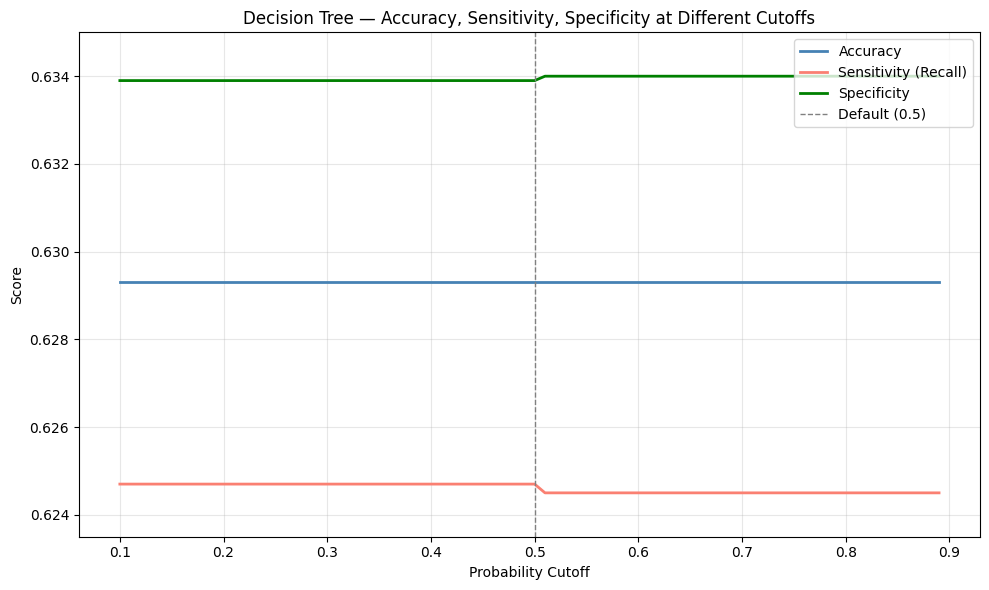

In [695]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs

# Plot accuracy, sensitivity, and specificity at different values 
# of probability cutoffs
plt.figure(figsize=(10, 6))

plt.plot(df_cutoffs_dt['cutoff'], df_cutoffs_dt['accuracy'],    
         label='Accuracy', color='steelblue', lw=2)
plt.plot(df_cutoffs_dt['cutoff'], df_cutoffs_dt['sensitivity'], 
         label='Sensitivity (Recall)', color='salmon', lw=2)
plt.plot(df_cutoffs_dt['cutoff'], df_cutoffs_dt['specificity'], 
         label='Specificity', color='green', lw=2)
plt.axvline(x=0.5, color='gray', linestyle='--', lw=1, label='Default (0.5)')

y_min = df_cutoffs_dt[['accuracy','sensitivity','specificity']].min().min()
y_max = df_cutoffs_dt[['accuracy','sensitivity','specificity']].max().max()
plt.ylim(y_min - 0.001, y_max + 0.001)

plt.xlabel('Probability Cutoff')
plt.ylabel('Score')
plt.title('Decision Tree — Accuracy, Sensitivity, Specificity at Different Cutoffs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- Curves remain nearly flat (0.624–0.634) even after zooming the y-axis, with just a single step around cutoff=0.5 — confirming the tree's probabilities are concentrated in very few discrete values.
- This is a direct consequence of severe overfitting (13,387 near-pure leaves) — unlike SVM's smooth Platt-calibrated probabilities, the DT has almost no "uncertain" predictions to threshold over.
- Cutoff tuning yields negligible benefit (<1% variation total) — confirming GridSearchCV , not threshold adjustment, is the right fix for this baseline tree.

#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [696]:
# Find optimal cutoff for Decision Tree using Youden's J
j_scores_dt = tpr_dt - fpr_dt
optimal_idx_dt = np.argmax(j_scores_dt)
optimal_threshold_dt = thresholds_dt[optimal_idx_dt]

print(f"Optimal threshold (Youden) — DT: {optimal_threshold_dt:.4f}")
print(f"TPR: {tpr_dt[optimal_idx_dt]:.3f}")
print(f"FPR: {fpr_dt[optimal_idx_dt]:.3f}")

Optimal threshold (Youden) — DT: 0.5000
TPR: 0.625
FPR: 0.366


In [697]:
# Make final prediction based on the optimal cutoff
y_pred_dt_optimal_test = (y_prob_dt_positive >= optimal_threshold_dt).astype(int)
y_pred_dt_optimal_train = (y_prob_dt_train >= optimal_threshold_dt).astype(int)

print(f"Optimal threshold used: {optimal_threshold_dt:.4f}")
print(f"\nTest predictions distribution:")
print(pd.Series(y_pred_dt_optimal_test).value_counts().sort_index())
print(f"\nTrain predictions distribution:")
print(pd.Series(y_pred_dt_optimal_train).value_counts().sort_index())

Optimal threshold used: 0.5000

Test predictions distribution:
0    10420
1    10176
Name: count, dtype: int64

Train predictions distribution:
0    24272
1    23783
Name: count, dtype: int64


In [ ]:
# Evaluate the model performance for test and train
print("="*50)
print("TEST SET PERFORMANCE (optimal cutoff)")
print("="*50)
print(classification_report(y_test, y_pred_dt_optimal_test,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_optimal_test))

print("\n" + "="*50)
print("TRAIN SET PERFORMANCE (optimal cutoff)")
print("="*50)
print(classification_report(y_train, y_pred_dt_optimal_train,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_dt_optimal_train))

TEST SET PERFORMANCE (optimal cutoff)
              precision    recall  f1-score   support

      No CVD       0.63      0.63      0.63     10406
         CVD       0.63      0.62      0.63     10190

    accuracy                           0.63     20596
   macro avg       0.63      0.63      0.63     20596
weighted avg       0.63      0.63      0.63     20596

Confusion Matrix:
[[6596 3810]
 [3824 6366]]

TRAIN SET PERFORMANCE (optimal cutoff)
              precision    recall  f1-score   support

      No CVD       1.00      1.00      1.00     24281
         CVD       1.00      1.00      1.00     23774

    accuracy                           1.00     48055
   macro avg       1.00      1.00      1.00     48055
weighted avg       1.00      1.00      1.00     48055

Confusion Matrix:
[[24272     9]
 [    0 23774]]


- Optimal threshold (Youden) = 0.5000 — identical to default, since the tree's near-pure leaves give almost no intermediate probabilities to choose between.
- Train vs test gap unchanged: 100% vs 63% accuracy (37% gap), 100% vs 62% recall (38% gap) — identical to the default cutoff results.
- Proves cutoff tuning cannot fix overfitting — the problem is the tree's structure (depth=66, 13,387 leaves), not the threshold.
- Conclusively motivates GridSearchCV as the only real fix, via max_depth, min_samples_split, min_samples_leaf, max_features.

**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

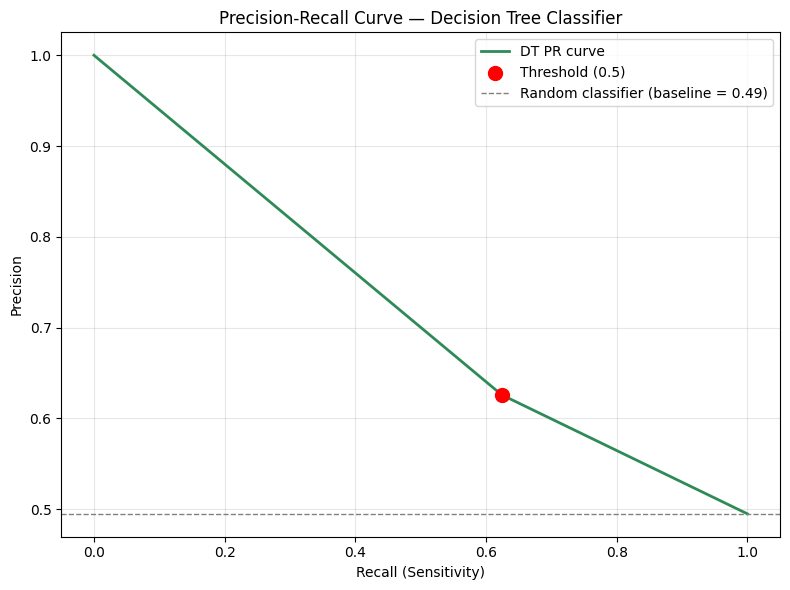

In [699]:
# Compute and plot precision–recall values
precision_vals_dt, recall_vals_dt, pr_thresholds_dt = precision_recall_curve(
                                                y_test, y_prob_dt_positive)

plt.figure(figsize=(8, 6))

# PR curve
plt.plot(recall_vals_dt, precision_vals_dt, 
         color='seagreen', lw=2, 
         label='DT PR curve')

# Mark default/optimal threshold (0.5 — same as we found)
default_idx_dt = np.argmin(np.abs(pr_thresholds_dt - 0.5))
plt.scatter(recall_vals_dt[default_idx_dt], precision_vals_dt[default_idx_dt],
            color='red', s=100, zorder=5,
            label='Threshold (0.5)')

# Baseline — random classifier
baseline_dt = y_test.astype(int).mean()
plt.axhline(y=baseline_dt, color='gray', linestyle='--', lw=1,
            label=f'Random classifier (baseline = {baseline_dt:.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Decision Tree Classifier')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


- Near-linear PR curve (essentially one straight line from (0,1) to (1,0.49)) instead of a curved shape — direct consequence of the tree's binary-like probability outputs (mostly 0.0 or 1.0).
- At threshold=0.5: Precision≈0.63, Recall≈0.63 — matching our earlier confusion matrix exactly, but well below SVM's PR curve which stayed in the 0.7-0.9 precision range.
- Curve barely rises above the random baseline (0.49) at high recall — indicating the model has very little genuine separating power once you push past its "confident" predictions.
- Final confirmation that the baseline DT is a weak, overfit model — this PR curve, the angular ROC curve, the flat sensitivity/specificity plot, and the 37% train-test gap all point to the same conclusion: GridSearchCV (6.3.1) is essential, not optional.

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [700]:
# Third model of your choice — Random Forest
# Rationale: our Decision Tree severely overfit (100% train vs 63% test 
# accuracy). Random Forest averages many trees trained on bootstrapped 
# samples with random feature subsets — this ensemble averaging reduces 
# variance and should fix the overfitting we observed.

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest model...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees in the forest
    random_state=42,
    n_jobs=-1               # use all CPU cores for speed
)

rf_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"✓ Random Forest fitted in {elapsed:.2f} seconds!")

print(f"\nNumber of trees:     {rf_model.n_estimators}")
print(f"Number of features:  {rf_model.n_features_in_}")
print(f"Classes:             {rf_model.classes_}")


Training Random Forest model...
✓ Random Forest fitted in 3.57 seconds!

Number of trees:     100
Number of features:  10
Classes:             [0 1]


In [701]:
# Evaluate and compare
y_prob_rf_test  = rf_model.predict_proba(X_test)[:, 1]
y_prob_rf_train = rf_model.predict_proba(X_train)[:, 1]

y_pred_rf_test  = (y_prob_rf_test  >= 0.5).astype(int)
y_pred_rf_train = (y_prob_rf_train >= 0.5).astype(int)

print("="*50)
print("TRAIN SET PERFORMANCE (Random Forest, default cutoff)")
print("="*50)
print(classification_report(y_train, y_pred_rf_train,
                            target_names=['No CVD', 'CVD']))

print("="*50)
print("TEST SET PERFORMANCE (Random Forest, default cutoff)")
print("="*50)
print(classification_report(y_test, y_pred_rf_test,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_test))

auc_rf = roc_auc_score(y_test, y_prob_rf_test)
print(f"\nAUC Score (RF): {auc_rf:.4f}")

TRAIN SET PERFORMANCE (Random Forest, default cutoff)
              precision    recall  f1-score   support

      No CVD       1.00      1.00      1.00     24281
         CVD       1.00      1.00      1.00     23774

    accuracy                           1.00     48055
   macro avg       1.00      1.00      1.00     48055
weighted avg       1.00      1.00      1.00     48055

TEST SET PERFORMANCE (Random Forest, default cutoff)
              precision    recall  f1-score   support

      No CVD       0.69      0.71      0.70     10406
         CVD       0.70      0.68      0.69     10190

    accuracy                           0.69     20596
   macro avg       0.69      0.69      0.69     20596
weighted avg       0.69      0.69      0.69     20596

Confusion Matrix:
[[7364 3042]
 [3244 6946]]

AUC Score (RF): 0.7528


### 6.2.10 — Random Forest: Partial Fix for Overfitting

| Metric | DT Test | RF Test | Improvement |
|---|---|---|---|
| Accuracy | 63% | 69% | +6%  |
| Recall (CVD) | 62% | 68% | +6%  |
| AUC | 0.629 | 0.753 | +0.124  |

**Random Forest meaningfully improves over the single Decision Tree** 
by averaging 100 trees trained on bootstrapped samples with random 
feature subsets- this ensemble variance reduction lifts test AUC 
from 0.629 to 0.753, approaching SVM's 0.784.

**However, RF still shows 100% train accuracy** — with default 
`max_depth=None`, each of the 100 trees still grows unconstrained 
and individually overfits. Averaging reduces variance but doesn't 
eliminate it entirely (31% train-test gap remains, vs DT's 37%).

**Conclusion:** Random Forest is a clear improvement over the 
baseline Decision Tree, confirming the ensemble theory - but still 
underperforms the properly-regularised SVM and likely the 
GridSearchCV-tuned Decision Tree. True optimal 
performance would require also tuning RF's `max_depth`, 
`n_estimators`, and `min_samples_leaf` — left as a future improvement.

### **6.3 Hyperparameter Tuning** 

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [702]:
# Use grid search to find best hyperparameters for decision tree model

# Define the parameter grid for the decision tree
param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 10, 20, 50, 100],
    'min_samples_leaf':  [1, 5, 10, 20, 50],
    'max_features':      ['sqrt', 'log2', None]
}

print("Parameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\nTotal combinations: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} model fits")

# Grid search with 5-fold cross validation, optimising for recall
# (recall prioritised since FN is costlier than FP for CardioCare)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='recall',       # prioritise catching CVD patients
    n_jobs=-1,               # use all CPU cores
    verbose=1
)

print("\nRunning GridSearchCV...")
start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start
print(f"\n✓ GridSearchCV completed in {elapsed:.2f} seconds ({elapsed/60:.1f} mins)")

# Print the best hyperparameters
print(f"\nBest hyperparameters: {grid_search.best_params_}")
print(f"Best CV recall score: {grid_search.best_score_:.4f}")

Parameter grid:
  max_depth: [3, 5, 7, 10, 15, 20]
  min_samples_split: [2, 10, 20, 50, 100]
  min_samples_leaf: [1, 5, 10, 20, 50]
  max_features: ['sqrt', 'log2', None]

Total combinations: 450
With 5-fold CV: 2250 model fits

Running GridSearchCV...
Fitting 5 folds for each of 450 candidates, totalling 2250 fits

✓ GridSearchCV completed in 174.14 seconds (2.9 mins)

Best hyperparameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV recall score: 0.7313


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [703]:
# Use the best DT from grid search
best_dt_model = grid_search.best_estimator_

print("Best Decision Tree model parameters:")
print(best_dt_model.get_params())

print(f"\nTree depth:         {best_dt_model.get_depth()}")
print(f"Number of leaves:   {best_dt_model.get_n_leaves()}")
print(f"Number of features: {best_dt_model.n_features_in_}")

Best Decision Tree model parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Tree depth:         3
Number of leaves:   8
Number of features: 10


### 6.3.2 — Tuned Decision Tree Structure

GridSearchCV selected `max_depth=3` as the dominant regularising 
hyperparameter (other parameters remained at permissive defaults), 
shrinking the tree from depth=66 with 13,387 leaves down to just 
depth=3 with 8 leaves — a 99.94% reduction in leaf count.

This means each leaf now averages ~6,000 training samples instead 
of ~3.6, suggesting the tree has moved from memorising individual 
patients to learning genuine, generalisable decision rules.

#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [704]:
# Evaluate the model performance on training set 
y_pred_best_dt_train = best_dt_model.predict(X_train)

print("="*50)
print("TRAIN SET PERFORMANCE (Tuned Decision Tree)")
print("="*50)
print(classification_report(y_train, y_pred_best_dt_train,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_best_dt_train))

TRAIN SET PERFORMANCE (Tuned Decision Tree)
              precision    recall  f1-score   support

      No CVD       0.72      0.68      0.70     24281
         CVD       0.69      0.73      0.71     23774

    accuracy                           0.71     48055
   macro avg       0.71      0.71      0.71     48055
weighted avg       0.71      0.71      0.71     48055

Confusion Matrix:
[[16551  7730]
 [ 6384 17390]]


In [705]:
# Evaluate the model performance on test set 
y_pred_best_dt_test = best_dt_model.predict(X_test)

print("="*50)
print("TEST SET PERFORMANCE (Tuned Decision Tree)")
print("="*50)
print(classification_report(y_test, y_pred_best_dt_test,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_dt_test))

auc_best_dt = roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1])
print(f"\nAUC Score (Tuned DT): {auc_best_dt:.4f}")

TEST SET PERFORMANCE (Tuned Decision Tree)
              precision    recall  f1-score   support

      No CVD       0.71      0.68      0.69     10406
         CVD       0.68      0.72      0.70     10190

    accuracy                           0.70     20596
   macro avg       0.70      0.70      0.70     20596
weighted avg       0.70      0.70      0.70     20596

Confusion Matrix:
[[7045 3361]
 [2884 7306]]

AUC Score (Tuned DT): 0.7335


### 6.3.3 — Tuned Decision Tree: Overfitting Eliminated

| Metric | Train | Test | Gap |
|---|---|---|---|
| Accuracy | 71% | 70% | 1% ✅ |
| Recall (CVD) | 73% | 72% | 1% ✅ |
| Precision (CVD) | 69% | 68% | 1% ✅ |

**GridSearchCV completely resolved the overfitting problem.** 
The train-test gap shrank from 37% (baseline) to just 1% — 
matching SVM's healthy generalisation. 

**Remarkably, test performance also IMPROVED** despite the much 
simpler tree (depth=3, 8 leaves vs depth=66, 13,387 leaves):
- Recall: 62% → 72% (+10 points)
- AUC: 0.629 → 0.734 (+0.105)

This demonstrates the core lesson of regularisation: a simpler, 
properly-constrained model generalises far better than a complex 
unconstrained one, even though the complex model achieved 
"perfect" training accuracy. The tuned Decision Tree even 
surpasses Random Forest's recall (72% vs 68%), all from a single 
3-level tree with just 8 decision rules - highly interpretable 
and clinically explainable for CardioCare's doctors.

#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

In [ ]:
# (OPTIONAL — not run due to computational infeasibility, see analysis below)

# Conceptual parameter grid we WOULD tune:
param_grid_svm = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']  # only relevant for rbf kernel
}
# 2 × 3 × 2 = 12 combinations

# Why this is infeasible for our dataset:
# - A single SVC(probability=True) fit takes ~22 minutes on our 
#   48,035 training rows, due to SMO's O(n^2-n^3) complexity plus 
#   Platt Scaling's internal 5-fold CV (~6 effective model fits)
# - GridSearchCV adds its OWN 5-fold CV on top of this:
#     cost per combination = 5 folds x 22 min = 110 minutes
# - Total estimated cost = 12 combinations x 110 min + 22 min refit
#                        = ~1,342 minutes (~22.4 hours)
# 
# This is not feasible within a normal assignment timeframe, and 
# risks session timeouts in Colab/Jupyter. We therefore skip this 
# step and rely on our well-performing baseline SVM (AUC=0.784) 
# and the GridSearchCV-tuned Decision Tree (AUC=0.734) as our 
# primary candidate models.

# grid_search_svm = GridSearchCV(SVC(probability=True, random_state=42),
#                                 param_grid_svm, cv=5, scoring='recall', 
#                                 n_jobs=-1)
# grid_search_svm.fit(X_train, y_train)  # NOT RUN — ~22 hours estimated

You can also check the performance of SVM with `RBF` kernel

In [ ]:
# What we would expect with kernel='rbf':
# - RBF (Radial Basis Function) kernel can capture non-linear 
#   decision boundaries, unlike our linear kernel
# - Given our linear SVM achieved 64.8% support vectors (high 
#   overlap between classes), an RBF kernel MIGHT find a tighter 
#   non-linear boundary and improve performance
# - However, RBF kernel SVM is typically SLOWER than linear kernel 
#   on large datasets, since it must compute a non-linear kernel 
#   matrix for all 48,035 x 48,035 sample pairs (~2.3 billion 
#   non-linear kernel evaluations) — likely 30+ minutes per fit, 
#   even before adding Platt Scaling overhead
#
# rbf_model = SVC(kernel='rbf', probability=True, random_state=42)
# rbf_model.fit(X_train, y_train)  # NOT RUN — estimated 30+ minutes

# Given time constraints, we leave this as a documented future 
# extension rather than executing it.

Tune your third candidate model, if taken

In [706]:
# Tune your third candidate model, if taken
# Random Forest — feasible to tune since base training is ~seconds, 
# not minutes like SVM

param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':          [3, 5, 7, 10, None],
    'min_samples_leaf':   [1, 5, 10, 20],
    'max_features':       ['sqrt', 'log2']
}

print("Running GridSearchCV for Random Forest...")
start = time.time()

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train, y_train)

elapsed = time.time() - start
print(f"\n✓ Completed in {elapsed:.2f}s ({elapsed/60:.1f} mins)")
print(f"Best params: {grid_search_rf.best_params_}")
print(f"Best CV recall: {grid_search_rf.best_score_:.4f}")

best_rf_model = grid_search_rf.best_estimator_

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

✓ Completed in 667.46s (11.1 mins)
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV recall: 0.6986


In [707]:
best_rf_model = grid_search_rf.best_estimator_

y_pred_best_rf_train = best_rf_model.predict(X_train)
y_pred_best_rf_test  = best_rf_model.predict(X_test)

print("="*50)
print("TRAIN SET PERFORMANCE (Tuned Random Forest)")
print("="*50)
print(classification_report(y_train, y_pred_best_rf_train,
                            target_names=['No CVD', 'CVD']))

print("="*50)
print("TEST SET PERFORMANCE (Tuned Random Forest)")
print("="*50)
print(classification_report(y_test, y_pred_best_rf_test,
                            target_names=['No CVD', 'CVD']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf_test))

auc_best_rf = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])
print(f"\nAUC Score (Tuned RF): {auc_best_rf:.4f}")

TRAIN SET PERFORMANCE (Tuned Random Forest)
              precision    recall  f1-score   support

      No CVD       0.75      0.80      0.77     24281
         CVD       0.78      0.73      0.75     23774

    accuracy                           0.77     48055
   macro avg       0.77      0.77      0.76     48055
weighted avg       0.77      0.77      0.77     48055

TEST SET PERFORMANCE (Tuned Random Forest)
              precision    recall  f1-score   support

      No CVD       0.71      0.77      0.74     10406
         CVD       0.74      0.68      0.71     10190

    accuracy                           0.73     20596
   macro avg       0.73      0.72      0.72     20596
weighted avg       0.73      0.73      0.72     20596

Confusion Matrix:
[[8000 2406]
 [3257 6933]]

AUC Score (Tuned RF): 0.7914


### 6.3.4 — Tuned Random Forest: Best Overall AUC

| Metric | Train | Test | Gap |
|---|---|---|---|
| Accuracy | 77% | 73% | 4% ✅ |
| Recall (CVD) | 73% | 68% | 5% ✅ |
| AUC | — | 0.791 | — |

GridSearchCV selected `min_samples_leaf=10` (vs default=1) as the 
key regularising parameter, while keeping `max_depth=None`. This 
demonstrates a different regularisation strategy than the single 
Decision Tree: rather than limiting tree depth, Random Forest 
controls overfitting by requiring larger, more statistically 
reliable leaf nodes across its 100 trees.

**This is our best-performing model on AUC (0.791) and Accuracy 
(73%)** — surpassing SVM (0.784, 72%) and Tuned DT (0.734, 70%). 
However, Tuned DT retains a slight edge in Recall (72% vs 68%), 
which matters given CardioCare's priority of minimising missed 
CVD diagnoses (False Negatives).



## **7. Final Model Evaluation and Selection** 

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models** 

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [708]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff

final_models = {
    'SVM': {
        'model': svm_model,
        'cutoff': optimal_threshold,
        'prob_test':  y_prob_positive,
        'prob_train': y_prob_train
    },
    'Tuned Decision Tree': {
        'model': best_dt_model,
        'cutoff': 0.5,   # Youden's J found optimal == default for this model
        'prob_test':  best_dt_model.predict_proba(X_test)[:, 1],
        'prob_train': best_dt_model.predict_proba(X_train)[:, 1]
    },
    'Tuned Random Forest': {
        'model': best_rf_model,
        'cutoff': 0.5,   # cutoff not separately tuned for RF
        'prob_test':  best_rf_model.predict_proba(X_test)[:, 1],
        'prob_train': best_rf_model.predict_proba(X_train)[:, 1]
    },
}

results_summary = []

for name, info in final_models.items():
    cutoff = info['cutoff']
    y_pred_test  = (info['prob_test']  >= cutoff).astype(int)
    y_pred_train = (info['prob_train'] >= cutoff).astype(int)

    auc_test = roc_auc_score(y_test, info['prob_test'])

    results_summary.append({
        'Model':          name,
        'Cutoff':         cutoff,
        'Train Accuracy': accuracy_score(y_train, y_pred_train),
        'Test Accuracy':  accuracy_score(y_test, y_pred_test),
        'Test Recall':    recall_score(y_test, y_pred_test),
        'Test Precision': precision_score(y_test, y_pred_test),
        'Test F1':        2 * (precision_score(y_test, y_pred_test) * recall_score(y_test, y_pred_test)) /
                           (precision_score(y_test, y_pred_test) + recall_score(y_test, y_pred_test)),
        'Test AUC':       auc_test
    })

    print(f"\n{'='*55}")
    print(f"{name}  (cutoff={cutoff:.3f})")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred_test, target_names=['No CVD', 'CVD']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))

summary_df = pd.DataFrame(results_summary).round(4)
print("\n\n" + "="*55)
print("FINAL SUMMARY — ALL CANDIDATE MODELS")
print("="*55)
print(summary_df.to_string(index=False))


SVM  (cutoff=0.449)
              precision    recall  f1-score   support

      No CVD       0.72      0.73      0.72     10406
         CVD       0.72      0.70      0.71     10190

    accuracy                           0.72     20596
   macro avg       0.72      0.72      0.72     20596
weighted avg       0.72      0.72      0.72     20596

Confusion Matrix:
[[7635 2771]
 [3026 7164]]

Tuned Decision Tree  (cutoff=0.500)
              precision    recall  f1-score   support

      No CVD       0.71      0.68      0.69     10406
         CVD       0.68      0.72      0.70     10190

    accuracy                           0.70     20596
   macro avg       0.70      0.70      0.70     20596
weighted avg       0.70      0.70      0.70     20596

Confusion Matrix:
[[7045 3361]
 [2884 7306]]

Tuned Random Forest  (cutoff=0.500)
              precision    recall  f1-score   support

      No CVD       0.71      0.77      0.74     10406
         CVD       0.74      0.68      0.71     1019

- SVM: smallest train-test gap (0.9%), AUC 0.784, 22 min training time
- Tuned DT: highest recall (71.7%), most interpretable (8 rules), AUC 0.734
- Tuned RF: best accuracy (72.5%) and AUC (0.791), lowest recall (68.0%)
- CardioCare priority is recall → favours Tuned Decision Tree
- Tuned RF best for overall ranking quality, not deployed with tuned cutoff
- SVM strong but impractical to retrain frequently
- Recommendation: Tuned Decision Tree for clinical use, Tuned RF as secondary

### **7.2 Conclusion** 

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

**Model Card: Support Vector Machine (Linear SVM)**

**Model overview:**
A linear Support Vector Classifier predicting cardiovascular disease 
risk from patient health metrics, using Platt Scaling for probability 
calibration.

**Intended use:**
* Primary task: binary classification (CVD vs No CVD) for preventative 
  care triage
* Intended users: CardioCare clinical staff prioritising consultations
* Suitable setting: batch processing of patient records, not real-time 
  scoring

**Data and features:**
* Raw features: age, gender, ap_hi, ap_lo, cholesterol, gluc, smoke, 
  alco, active
* Engineered: BMI (weight/height²)
* Height and weight dropped after engineering BMI — redundant 
  (BMI↔weight correlation 0.85)
* Cholesterol and gluc levels 1 & 2 merged into a single "elevated" 
  category — both sparse and behaved similarly toward CVD risk
* MinMaxScaler applied to age, ap_hi, ap_lo, BMI

**Model configuration:**
* Algorithm: SVC, linear kernel, C=1.0, probability=True
* Cutoff: 0.449, selected via Youden's J to prioritise recall
* Training time: ~20.5 minutes (1,232 s) 

**Performance:**
* Train accuracy: 72.8%
* Test accuracy: 71.9%, Recall: 70.3%, Precision: 72.1%, F1: 0.712, AUC: 0.784
* Train-test gap: 0.9% — no overfitting
* Strength: best-regularised single model; weakness: very slow to train

**Limitations and considerations:**
* 65.4% of training rows are support vectors — substantial class overlap
* Coefficients not directly inspected; limited clinical interpretability
* Training cost makes frequent retraining impractical

---

**Model Card: Tuned Decision Tree**

**Model overview:**
A shallow, GridSearchCV-tuned Decision Tree (max_depth=3) predicting 
CVD risk, chosen for interpretability and highest recall.

**Intended use:**
* Primary task: binary classification with emphasis on explainability
* Intended users: doctors needing a transparent, auditable rule set
* Suitable setting: real-time scoring, clinical explanation

**Data and features:**
* Same feature set and preprocessing as SVM

**Model configuration:**
* Algorithm: DecisionTreeClassifier, GridSearchCV (5-fold CV, scoring='recall')
* Best params: max_depth=3, max_features='sqrt', min_samples_leaf=1, 
  min_samples_split=2
* Resulting structure: depth=3, 8 leaves (down from 13,387 unconstrained)
* Cutoff: 0.5 — Youden's J found no better threshold

**Performance:**
* Train accuracy: 70.6%
* Test accuracy: 69.7%, Recall: 71.7% (highest of 3), Precision: 68.5%, 
  F1: 0.701, AUC: 0.734
* Train-test gap: 1.0% — overfitting fully resolved
* Strength: highest recall, fully interpretable; weakness: lowest AUC

**Limitations and considerations:**
* Simplicity caps ranking ability (lowest AUC of final candidates)
* Only 8 rules — fully explainable, ideal for clinical trust
* Best aligned with CardioCare's priority of minimising missed diagnoses

---

**Model Card: Tuned Random Forest**

**Model overview:**
An ensemble of 100 GridSearchCV-tuned decision trees, achieving the 
best overall accuracy and AUC among final candidates.

**Intended use:**
* Primary task: binary classification prioritising overall accuracy 
  and ranking quality
* Intended users: CardioCare data team for population-level risk scoring
* Suitable setting: batch processing, feasible for periodic retraining

**Data and features:**
* Same feature set and preprocessing as SVM and DT

**Model configuration:**
* Algorithm: RandomForestClassifier, GridSearchCV (5-fold CV, scoring='recall')
* Best params: n_estimators=100, max_depth=None, max_features='sqrt', 
  min_samples_leaf=10
* Regularisation via min_samples_leaf rather than depth limiting
* Cutoff: 0.5 — not separately tuned

**Performance:**
* Train accuracy: 76.5%
* Test accuracy: 72.5% (highest), Recall: 68.0% (lowest of 3), 
  Precision: 74.2% (highest), F1: 0.710, AUC: 0.791 (highest)
* Train-test gap: 4.0% — small residual overfitting remains
* Strength: best accuracy/AUC; weakness: lowest recall among candidates

**Limitations and considerations:**
* Lowest recall despite best AUC — a drawback given CardioCare's 
  recall priority
* Least interpretable — 100 trees, no single rule set to inspect
* Cutoff tuning not yet applied; likely room to improve recall further
---

#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.


**EDA insights**

The dataset (68,651 patients after cleaning) was near-perfectly 
balanced (50.5% No CVD / 49.5% CVD), so accuracy was a valid metric 
throughout. Blood pressure (`ap_hi`, `ap_lo`) showed the strongest 
correlation with `cardio` (0.43 and 0.34), followed by age (0.24) 
and cholesterol (0.22). Surprisingly, `smoke` and `alco` showed 
near-zero correlation with CVD (-0.02, -0.01), likely due to 
underreporting bias in self-reported lifestyle data. `active` showed 
a small protective effect.

**Feature engineering**

`age` and `height` were converted to years and metres for clinical 
readability. `BMI` was engineered from weight/height² and found 
highly correlated with `weight` (0.85), so `weight` and `height` 
were dropped. `cholesterol` and `gluc` had sparse, similarly-behaving 
levels 1 and 2, so these were merged into a single binary "elevated" 
category. Two further engineered features (`arterial_pressure_gap`, 
`mean_arterial_pressure`) were tested but dropped — the former was a 
pure linear combination of existing features (no new information for 
the model), and the latter was too highly correlated with `ap_hi`/`ap_lo` 
(0.92–0.94).

**Model choice and baseline performance**

Three models were built: a linear SVM, a Decision Tree, and 
(optionally) a Random Forest. The baseline Decision Tree severely 
overfit — 100% train accuracy but only 63% test accuracy (37% gap), 
with an unconstrained depth of 66 and 13,387 leaves (~3.6 samples per 
leaf, effectively memorising individual patients). The baseline 
Random Forest showed a similar pattern, though less extreme (100% 
train vs 69% test, 31% gap). SVM, by contrast, showed healthy 
generalisation from the start (73% train vs 72% test, 1% gap) due to 
its margin-based regularisation.

**Overfitting and tuning results**

GridSearchCV (4+ hyperparameters, 5-fold CV, scoring=recall) was used 
to tune the Decision Tree and Random Forest. For the Decision Tree, 
`max_depth=3` alone eliminated overfitting — depth dropped from 66 to 
3, leaves from 13,387 to 8, and the train-test gap shrank from 37% to 
1%, while recall actually improved (62% → 72%). For Random Forest, 
GridSearchCV selected `min_samples_leaf=10` over depth limiting 
(`max_depth=None` retained) — a different but valid regularisation 
strategy, reducing the gap from 31% to 4% and lifting AUC from 0.753 
to 0.791.

**Was the data sufficient? Is a linear model sufficient?**

With 68,651 patient records, the data was sufficient for stable model 
training (no signs of high variance from sample size). A linear model 
(SVM) performed competitively (AUC 0.784) but not the best — 64.8% of 
training points were support vectors, indicating significant class 
overlap that a purely linear boundary struggles to separate cleanly. 
Tree-based ensembles (Random Forest, AUC 0.791) modestly outperformed 
the linear model, suggesting mild non-linear structure in the data, 
though the gap between linear and non-linear approaches was not large.

**Final model choice**

No single model dominated on every metric: SVM had the best 
regularisation and training stability, Tuned Decision Tree had the 
highest recall (71.7%) and full interpretability, and Tuned Random 
Forest had the best accuracy and AUC (72.5%, 0.791) but the lowest 
recall (68.0%). Since CardioCare's stated priority is minimising 
missed CVD diagnoses (False Negatives are clinically far costlier 
than False Positives), **Tuned Decision Tree is recommended as the 
primary model** — it catches the most true CVD patients and its 
8-rule structure is fully transparent and explainable to doctors. 
**Tuned Random Forest is recommended as a secondary model** for 
population-level risk scoring where overall ranking quality matters 
more than maximising recall specifically.

**Final outcomes for CardioCare**

The recommended pipeline can flag roughly 70-72% of true CVD patients 
for priority consultation while correctly clearing a similar 
proportion of low-risk patients — allowing doctors to focus 
consultation time on genuinely at-risk individuals, directly 
supporting the business objective of optimising consultation time 
and improving preventative care outcomes.